# 🏥 Project: Predicting Extubation Failure (MIMIC-IV)
### 👨‍💻 Team Members & Roles:
1. **Saad (Team Lead):** Data Extraction (SQL), Final Integration, and Report Writing.
2. **Nawaf (Model Interpreter):** Model Interpretability (SHAP Values) & Advanced Evaluation.
3. **Faisal (Data Engineer):** Data Cleaning, Missing Values, and Feature Engineering (e.g., RSBI).
4. **Abbas (Data Analyst):** Exploratory Data Analysis (EDA) and Statistical Visualizations.
5. **Mohammed (ML Modeler):** Building and Tuning Machine Learning Models (XGBoost, Random Forest).

### 🔗 Project Resources:
* **GitHub Repository:** [Predicting-Extubation-Failure](https://github.com/UIUO0/Predicting-Extubation-Failure)
* **Dataset:** PhysioNet (MIMIC-IV)

In [1]:
# ── Import Essential Libraries ─────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split

# ── Define Path (relative to notebook location) ────────────
DATA_PATH = "mimic_data.csv"
print(f'📁 Working directory : {os.getcwd()}')
print(f'📄 Data file         : {DATA_PATH}')
print(f'   File exists?      : {os.path.exists(DATA_PATH)}')

📁 Working directory : /Users/uiuo/Documents/GitHub/Predicting-Extubation-Failure
📄 Data file         : mimic_data.csv
   File exists?      : True


🛑 IMPORTANT: DATA EXTRACTION NOTICE

This cell was executed by the Team Lead (Saad) to fetch the master dataset from PhysioNet/BigQuery.

Status: Completed ✅

Action: The file mimic_data.csv is already generated and saved in the shared Google Drive folder.

Instruction: DO NOT re-run this cell. Re-running it will consume cloud resources and might overwrite any cleaning progress.

Proceed directly to the Data Cleaning & EDA section.

In [2]:
# # ==========================================
# # 🛠️ Task: Data Extraction (All Vitals + Labs + Vent Settings)
# # 👨‍💻 Done by: Saad (Team Lead)
# # ==========================================

# from google.colab import auth
# from google.colab import drive
# from google.cloud import bigquery
# import pandas as pd
# import os

# # 1. Authentication and Drive mount
# auth.authenticate_user()
# drive.mount('/content/drive')

# project_id = 'predicting-extubation-failure' # Ensure this is the correct Project ID
# client = bigquery.Client(project=project_id)

# print('⌛ Extracting the Ultimate Clinical Dataset from PhysioNet...')
# print('⚠️ This query scans millions of medical records. It may take a couple of minutes, please wait...')

# # 2. The Master SQL Query
# query = """
# WITH first_extubation AS (
#   SELECT subject_id, stay_id, starttime AS extubation_time,
#          ROW_NUMBER() OVER(PARTITION BY stay_id ORDER BY starttime) as rank
#   FROM `physionet-data.mimiciv_3_1_icu.procedureevents`
#   WHERE itemid IN (227194, 225468, 225477)
# ),
# target_events AS (
#   SELECT fe.stay_id,
#     MAX(CASE WHEN ie.intime BETWEEN fe.extubation_time AND DATETIME_ADD(fe.extubation_time, INTERVAL 72 HOUR) THEN 1 ELSE 0 END) as reintubated,
#     MAX(CASE WHEN ad.deathtime BETWEEN fe.extubation_time AND DATETIME_ADD(fe.extubation_time, INTERVAL 72 HOUR) THEN 1 ELSE 0 END) as died
#   FROM first_extubation fe
#   JOIN `physionet-data.mimiciv_3_1_icu.icustays` ie ON fe.stay_id = ie.stay_id
#   JOIN `physionet-data.mimiciv_3_1_hosp.admissions` ad ON fe.subject_id = ad.subject_id
#   WHERE fe.rank = 1 GROUP BY fe.stay_id
# ),
# demographics AS (
#   SELECT subject_id, gender, anchor_age FROM `physionet-data.mimiciv_3_1_hosp.patients`
# ),
# clinical_data_24h AS (
#   SELECT
#     fe.stay_id,
#     -- 1. Vitals
#     ROUND(AVG(CASE WHEN ce.itemid = 220045 THEN ce.valuenum END), 2) AS avg_heart_rate,
#     ROUND(AVG(CASE WHEN ce.itemid = 220210 THEN ce.valuenum END), 2) AS avg_resp_rate,
#     ROUND(AVG(CASE WHEN ce.itemid = 220277 THEN ce.valuenum END), 2) AS avg_spo2,
#     ROUND(AVG(CASE WHEN ce.itemid IN (220052, 220181, 225312) THEN ce.valuenum END), 2) AS avg_map,
#     ROUND(AVG(CASE WHEN ce.itemid = 223762 THEN ce.valuenum WHEN ce.itemid = 223761 THEN (ce.valuenum - 32) / 1.8 END), 2) AS avg_temp_c,
#
#     -- 2. Blood Gas
#     ROUND(AVG(CASE WHEN ce.itemid = 223830 THEN ce.valuenum END), 2) AS avg_ph,
#     ROUND(AVG(CASE WHEN ce.itemid = 220224 THEN ce.valuenum END), 2) AS avg_pao2,
#     ROUND(AVG(CASE WHEN ce.itemid = 220235 THEN ce.valuenum END), 2) AS avg_paco2,
#
#     -- 3. Ventilator Settings - (Crucial!)
#     ROUND(AVG(CASE WHEN ce.itemid = 223835 THEN ce.valuenum END), 2) AS avg_fio2,
#     ROUND(AVG(CASE WHEN ce.itemid = 220339 THEN ce.valuenum END), 2) AS avg_peep,
#     ROUND(AVG(CASE WHEN ce.itemid IN (224685, 224684, 224686) THEN ce.valuenum END), 2) AS avg_tidal_volume,
#
#     -- 4. Key Labs
#     ROUND(AVG(CASE WHEN ce.itemid = 220228 THEN ce.valuenum END), 2) AS avg_hemoglobin,
#     ROUND(AVG(CASE WHEN ce.itemid = 220546 THEN ce.valuenum END), 2) AS avg_wbc
#   FROM first_extubation fe
#   JOIN `physionet-data.mimiciv_3_1_icu.chartevents` ce ON fe.stay_id = ce.stay_id
#   WHERE ce.charttime BETWEEN DATETIME_SUB(fe.extubation_time, INTERVAL 24 HOUR) AND fe.extubation_time
#   -- This line speeds up the search across billions of rows
#   AND ce.itemid IN (220045, 220210, 220277, 220052, 220181, 225312, 223761, 223762, 223830, 220224, 220235, 223835, 220339, 224685, 224684, 224686, 220228, 220546)
#   GROUP BY fe.stay_id
# )
# SELECT
#   fe.subject_id, fe.stay_id, fe.extubation_time,
#   d.anchor_age AS age, d.gender,
#   c.* EXCEPT(stay_id),
#   GREATEST(COALESCE(te.reintubated, 0), COALESCE(te.died, 0)) as failure_label
# FROM first_extubation fe
# LEFT JOIN target_events te ON fe.stay_id = te.stay_id
# LEFT JOIN demographics d ON fe.subject_id = d.subject_id
# LEFT JOIN clinical_data_24h c ON fe.stay_id = c.stay_id
# WHERE fe.rank = 1
# """

# # 3. Execution and Saving
# df = client.query(query).to_dataframe()
# print(f'✅ Ultimate dataset extracted successfully! Number of cases: {len(df)}')

# dir_path = '/content/drive/MyDrive/ML Project'
# os.makedirs(dir_path, exist_ok=True)
# file_path = os.path.join(dir_path, 'mimic_data.csv')
# df.to_csv(file_path, index=False)
# print(f'💾 Master database saved successfully to: {file_path}')

# # Display the new data shape
# print(f"Number of columns now: {df.shape[1]}")
# display(df.head())

In [3]:
import os
print(f'📁 Working directory: {os.getcwd()}')
print(f'📂 Files available  : {[f for f in os.listdir(".") if f.endswith(".csv") or f.endswith(".ipynb")]}')

📁 Working directory: /Users/uiuo/Documents/GitHub/Predicting-Extubation-Failure
📂 Files available  : ['Predicting_Extubation_Failure.ipynb', 'mimic_data_cleaned_v2.csv', 'mimic_test.csv', 'mimic_data.csv', 'mimic_train.csv']


# 🛠️ Phase 2: Data Cleaning & Feature Engineering
**Assigned to: Faisal**

Hello Faisal! The master dataset has been successfully extracted from PhysioNet and includes all vital signs, blood gas labs, and ventilator settings.

**Your Tasks:**
1. **Handling Missing Values (Imputation):** Use appropriate imputation techniques (like median or mean) to fill in any missing values, especially for the lab results.
2. **Data Encoding:** Convert the `gender` column from categorical (M/F) to numerical (1/0).
3. **Feature Engineering (Crucial Step):** Since we have `avg_tidal_volume` and `avg_resp_rate`, please calculate the **RSBI (Rapid Shallow Breathing Index)**. *(Note: RSBI = Respiratory Rate / Tidal Volume in Liters).*

**Output Goal:** A 100% clean, numerically encoded DataFrame ready for EDA and Modeling.

In [4]:
import pandas as pd
import numpy as np
import os

DATA_PATH = 'mimic_data.csv'

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f'✅ Loaded from: {DATA_PATH}')
    print(f'Shape: {df.shape}')
    display(df.head())
else:
    print(f'❌ Error: mimic_data.csv not found.')
    print(f'   Current directory : {os.getcwd()}')
    print(f'   Files found       : {os.listdir(".")}')

✅ Loaded from: mimic_data.csv
Shape: (24305, 19)


,subject_id,stay_id,extubation_time,age,gender,avg_heart_rate,avg_resp_rate,avg_spo2,avg_map,avg_temp_c,avg_ph,avg_pao2,avg_paco2,avg_fio2,avg_peep,avg_tidal_volume,avg_hemoglobin,avg_wbc,failure_label
0,14619085,30069144,2164-12-02 09:00:00,76,M,54.02,26.05,84.97,62.21,35.81,7.05,81.60,38.40,86.83,5.0,434.50,8.3,6.40,1
1,17989998,30368380,2173-04-07 17:35:00,84,F,54.00,16.00,99.87,73.56,36.36,7.51,159.25,29.50,63.33,5.0,397.00,10.5,4.80,0
2,17439310,30494933,2134-08-02 08:33:00,62,M,84.11,16.00,99.50,87.78,36.97,7.55,157.00,27.00,40.00,5.0,519.50,10.8,5.40,0
3,19497110,31204542,2146-01-19 21:10:00,75,M,68.44,15.79,96.46,72.68,36.38,7.23,140.25,36.00,36.67,5.0,443.08,8.2,33.95,1
4,17218341,32118180,2113-04-03 19:03:00,53,F,113.17,28.80,56.59,78.66,36.77,7.27,107.14,47.43,69.29,18.0,435.58,8.6,24.13,0


In [5]:
# ── Step 1: Drop non-feature column ───────────────────────
df = df.drop(columns=['extubation_time'])

# ── Step 2: Encode gender ──────────────────────────────────
df['gender'] = df['gender'].map({'M': 1, 'F': 0})
print('✅ Gender encoded: M=1, F=0')

✅ Gender encoded: M=1, F=0


In [6]:
# ── Step 3: HIPAA Age Fix ─────────────────────────────────
# MIMIC-IV masks ages > 89 as 91 for patient privacy (HIPAA)
# We add a binary flag to preserve this information for the model
print(f'Patients with HIPAA-masked age (91): {(df["age"] == 91).sum()}')
df['age_masked'] = (df['age'] == 91).astype(int)
print('✅ age_masked column added (1 = HIPAA-protected patient)')

Patients with HIPAA-masked age (91): 543
✅ age_masked column added (1 = HIPAA-protected patient)


In [7]:
# ── Step 4: Sentinel Handling + Physiological Outlier Capping ──
# Action Plan 1.1 — sentinel codes (e.g. 999,999) in MIMIC labs mean "missing"
# Action Plan 1.2 — apply medically-grounded bounds for ALL clinical columns
# Anything outside the plausible physiological range → NaN (imputed in Step 6)

CLINICAL_BOUNDS = {
    'avg_heart_rate'  : (20,   250),    # bpm
    'avg_resp_rate'   : (1,    60),     # breaths/min
    'avg_spo2'        : (40,   100),    # %
    'avg_map'         : (20,   200),    # mmHg
    'avg_temp_c'      : (25,   45),     # °C
    'avg_ph'          : (6.5,  7.8),    # arterial pH
    'avg_pao2'        : (30,   700),    # mmHg
    'avg_paco2'       : (10,   150),    # mmHg
    'avg_fio2'        : (21,   100),    # %
    'avg_peep'        : (0,    30),     # cmH2O
    'avg_tidal_volume': (50,   2000),   # mL
    'avg_hemoglobin'  : (3,    25),     # g/dL
    'avg_wbc'         : (0.5,  100),    # x10^9/L
}

before_nan = df[list(CLINICAL_BOUNDS)].isnull().sum().sum()
for col, (lo, hi) in CLINICAL_BOUNDS.items():
    bad_mask = (df[col] < lo) | (df[col] > hi)
    n_bad = int(bad_mask.sum())
    df.loc[bad_mask, col] = np.nan
    if n_bad > 0:
        print(f'   {col:20s}: {n_bad:>6} value(s) outside [{lo}, {hi}] → NaN')
after_nan = df[list(CLINICAL_BOUNDS)].isnull().sum().sum()
print(f'\n✅ Sentinel + physiological capping done | NaN count: {before_nan} → {after_nan}')

   avg_heart_rate      :      3 value(s) outside [20, 250] → NaN
   avg_resp_rate       :      4 value(s) outside [1, 60] → NaN
   avg_spo2            :      8 value(s) outside [40, 100] → NaN
   avg_map             :      5 value(s) outside [20, 200] → NaN
   avg_temp_c          :     48 value(s) outside [25, 45] → NaN
   avg_ph              :      5 value(s) outside [6.5, 7.8] → NaN
   avg_pao2            :      7 value(s) outside [30, 700] → NaN
   avg_paco2           :      4 value(s) outside [10, 150] → NaN
   avg_fio2            :      6 value(s) outside [21, 100] → NaN
   avg_tidal_volume    :     78 value(s) outside [50, 2000] → NaN
   avg_hemoglobin      :      7 value(s) outside [3, 25] → NaN
   avg_wbc             :     49 value(s) outside [0.5, 100] → NaN

✅ Sentinel + physiological capping done | NaN count: 22887 → 23111


In [8]:
# ── Step 5: Train/Test Split FIRST (prevent data leakage) ─
# ⚠️ Must split BEFORE computing medians to avoid leakage
X = df.drop(columns=['failure_label'])
y = df['failure_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'✅ Split done | Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

✅ Split done | Train: 19444 | Test: 4861


In [9]:
# ── Step 6: Missingness Indicators + MICE (Iterative) Imputation ──
# Action Plan 2.1 — missingness itself can be predictive; add binary
#                   "<col>_was_missing" flags BEFORE imputation.
# Action Plan 2.2 — replace simple Median imputation with MICE
#                   (sklearn IterativeImputer): each missing column is
#                   regressed on the others iteratively → preserves
#                   joint distributions and inter-feature relationships
#                   far better than column-wise medians.
# IMPORTANT: imputer is FIT on train only, then APPLIED to test (no leakage).

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

exclude_from_imputation = ['subject_id', 'stay_id']
impute_cols = [c for c in X_train.select_dtypes(include=[np.number]).columns
               if c not in exclude_from_imputation]

# 1) Missingness indicator columns (only for cols that actually have NaN in train)
miss_cols = [c for c in impute_cols if X_train[c].isnull().any()]
for c in miss_cols:
    flag = f'{c}_was_missing'
    X_train[flag] = X_train[c].isnull().astype(int)
    X_test[flag]  = X_test[c].isnull().astype(int)
print(f'✅ Missingness indicators added for {len(miss_cols)} columns')

# 2) MICE imputation — fit on TRAIN only, apply to both
mice = IterativeImputer(
    estimator    = BayesianRidge(),
    max_iter     = 15,
    random_state = 42,
    sample_posterior = False,
    tol          = 1e-3,
    initial_strategy = 'median',
)
X_train[impute_cols] = mice.fit_transform(X_train[impute_cols])
X_test[impute_cols]  = mice.transform(X_test[impute_cols])

# Re-clip imputed values back to physiological bounds (MICE can extrapolate)
for col, (lo, hi) in CLINICAL_BOUNDS.items():
    if col in X_train.columns:
        X_train[col] = X_train[col].clip(lower=lo, upper=hi)
        X_test[col]  = X_test[col].clip(lower=lo, upper=hi)

print('✅ MICE (IterativeImputer) imputation complete')
print(f'   Missing in train: {X_train.isnull().sum().sum()}')
print(f'   Missing in test : {X_test.isnull().sum().sum()}')
print(f'   Iterations used : {mice.n_iter_}')

✅ Missingness indicators added for 13 columns
✅ MICE (IterativeImputer) imputation complete
   Missing in train: 0
   Missing in test : 0
   Iterations used : 4


In [10]:
# ── Step 7: Feature Engineering — RSBI + P/F Ratio ──
# 7a. RSBI = Resp Rate / (Tidal Volume in L)        → ≥105 = high failure risk
# 7b. P/F Ratio = PaO2 / (FiO2 fraction)            → <300 ARDS spectrum
#     (Action Plan 2.4 — replaces the multicollinear PaO2 + FiO2 pair
#      with a single, clinically meaningful oxygenation index)
# Both safeguard against division-by-zero with epsilon.

epsilon = 1e-6

for split_X in [X_train, X_test]:
    # RSBI
    tv_L = split_X['avg_tidal_volume'] / 1000.0
    split_X['rsbi'] = split_X['avg_resp_rate'] / (tv_L + epsilon)
    split_X['rsbi'] = split_X['rsbi'].clip(upper=500)

    # P/F Ratio (FiO2 stored as a percent → divide by 100 to get fraction)
    fio2_frac = split_X['avg_fio2'] / 100.0
    split_X['pf_ratio'] = split_X['avg_pao2'] / (fio2_frac + epsilon)
    split_X['pf_ratio'] = split_X['pf_ratio'].clip(upper=600)

print('✅ RSBI + P/F Ratio engineered (÷0 safe, clipped)')
print(f'\n   Train RSBI stats:\n{X_train["rsbi"].describe().round(2)}')
print(f'\n   Train P/F Ratio stats:\n{X_train["pf_ratio"].describe().round(2)}')

✅ RSBI + P/F Ratio engineered (÷0 safe, clipped)

   Train RSBI stats:
count    19444.00
mean        39.61
std         13.84
min          5.41
25%         30.50
50%         37.14
75%         46.06
max        190.47
Name: rsbi, dtype: float64

   Train P/F Ratio stats:
count    19444.00
mean       339.01
std        111.74
min         30.00
25%        258.33
50%        334.81
75%        410.48
max        600.00
Name: pf_ratio, dtype: float64


In [11]:
# ── Step 7b: Multicollinearity Check (VIF) ─────────────────
# Action Plan 2.3 — Variance Inflation Factor analysis.
# VIF_i = 1 / (1 - R²_i)  where R²_i = variance of feature_i
# explained by all other features (computed via LinearRegression).
# Pure sklearn implementation — no statsmodels dependency needed.
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

def compute_vif(df_vif: pd.DataFrame) -> pd.DataFrame:
    cols = list(df_vif.columns)
    vif_values = []
    for col in cols:
        others = [c for c in cols if c != col]
        y = df_vif[col].values
        X_others = df_vif[others].values
        r2 = LinearRegression().fit(X_others, y).score(X_others, y)
        vif_values.append(1.0 / (1.0 - r2) if r2 < 1.0 else np.inf)
    return pd.DataFrame({'feature': cols, 'VIF': vif_values})\
             .sort_values('VIF', ascending=False)\
             .reset_index(drop=True)

vif_exclude = {'subject_id', 'stay_id', 'age_masked'}
vif_exclude |= {c for c in X_train.columns if c.endswith('_was_missing')}

vif_features = [c for c in X_train.columns
                if c not in vif_exclude and X_train[c].nunique() > 1]

vif_data = compute_vif(X_train[vif_features].astype(float))
vif_data['VIF'] = vif_data['VIF'].round(2)

print('📐 Variance Inflation Factor (VIF) on training features:')
print(vif_data.to_string(index=False))

high_vif = vif_data[vif_data['VIF'] > 10]
if len(high_vif) > 0:
    print(f'\n⚠️  {len(high_vif)} feature(s) with VIF > 10 (multicollinearity):')
    print(high_vif.to_string(index=False))
    print('   → kept for tree-based models (robust to collinearity); '
          'flagged for SHAP interpretation in Phase 5.')
else:
    print('\n✅ No feature exceeds VIF > 10 — multicollinearity is acceptable.')

📐 Variance Inflation Factor (VIF) on training features:
         feature   VIF
        avg_pao2 11.29
        pf_ratio 10.61
            rsbi  8.85
        avg_fio2  5.77
   avg_resp_rate  5.29
avg_tidal_volume  3.28
          avg_ph  1.45
        avg_spo2  1.40
      avg_temp_c  1.38
       avg_paco2  1.27
          gender  1.27
        avg_peep  1.27
  avg_heart_rate  1.20
         avg_map  1.17
             age  1.16
  avg_hemoglobin  1.14
         avg_wbc  1.11

⚠️  2 feature(s) with VIF > 10 (multicollinearity):
 feature   VIF
avg_pao2 11.29
pf_ratio 10.61
   → kept for tree-based models (robust to collinearity); flagged for SHAP interpretation in Phase 5.


In [12]:
# ── Step 8: Verify & Export ────────────────────────────────
import os

df_train_clean = X_train.assign(failure_label=y_train.values)
df_test_clean  = X_test.assign(failure_label=y_test.values)
df_full_clean  = pd.concat([df_train_clean, df_test_clean]).sort_index()

print('=' * 50)
print('✅ CLEAN DATASET — READY FOR EDA & MODELING')
print('=' * 50)
print(f'Shape         : {df_full_clean.shape}')
print(f'Missing values: {df_full_clean.isnull().sum().sum()}')
print(f'All numeric   : {all(df_full_clean.dtypes != object)}')

# ── Save locally (same folder as notebook) ─────────────────
SAVE_DIR = '.'

df_full_clean.to_csv(  f'{SAVE_DIR}/mimic_data_cleaned_v2.csv', index=False)
df_train_clean.to_csv( f'{SAVE_DIR}/mimic_train.csv',           index=False)
df_test_clean.to_csv(  f'{SAVE_DIR}/mimic_test.csv',            index=False)

print('\n📁 Files saved:')
print(f'   mimic_data_cleaned_v2.csv  → Abbas (EDA)')
print(f'   mimic_train.csv            → Mohammed (ML training)')
print(f'   mimic_test.csv             → Mohammed (ML testing)')
display(df_full_clean.head())

✅ CLEAN DATASET — READY FOR EDA & MODELING
Shape         : (24305, 34)
Missing values: 0
All numeric   : True

📁 Files saved:
   mimic_data_cleaned_v2.csv  → Abbas (EDA)
   mimic_train.csv            → Mohammed (ML training)
   mimic_test.csv             → Mohammed (ML testing)


,subject_id,stay_id,age,gender,avg_heart_rate,avg_resp_rate,avg_spo2,avg_map,avg_temp_c,avg_ph,...,avg_pao2_was_missing,avg_paco2_was_missing,avg_fio2_was_missing,avg_peep_was_missing,avg_tidal_volume_was_missing,avg_hemoglobin_was_missing,avg_wbc_was_missing,rsbi,pf_ratio,failure_label
0,14619085,30069144,76.0,1.0,54.02,26.05,84.97,62.21,35.81,7.05,...,0,0,0,0,0,0,0,59.953832,93.976628,1
1,17989998,30368380,84.0,0.0,54.00,16.00,99.87,73.56,36.36,7.51,...,0,0,0,0,0,0,0,40.302165,251.460206,0
2,17439310,30494933,62.0,1.0,84.11,16.00,99.50,87.78,36.97,7.55,...,0,0,0,0,0,0,0,30.798786,392.499019,0
3,19497110,31204542,75.0,1.0,68.44,15.79,96.46,72.68,36.38,7.23,...,0,0,0,0,0,0,0,35.636825,382.464187,1
4,17218341,32118180,53.0,0.0,113.17,28.80,56.59,78.66,36.77,7.27,...,0,0,0,0,0,0,0,66.118586,154.625264,0


# 📊 Phase 3: Exploratory Data Analysis (EDA)
**Assigned to: Abbas**

Hello Abbas! The data is now clean and fully engineered. Your goal is to visualize this data so we can include these plots in our final project report.

**Your Tasks:**
1. **Target Distribution:** Plot the distribution of `failure_label` to visually demonstrate the class imbalance to the professor (Success vs. Failure).
2. **Correlation Matrix:** Create a heatmap to identify which features (e.g., RSBI, pH, SpO2) are most strongly correlated with extubation failure.
3. **Feature Comparisons:** Generate Boxplots or Violin plots comparing the vital signs of patients who succeeded vs. those who failed.

**Output Goal:** 3 to 4 high-quality, clearly labeled visualizations for the final report.

In [13]:
# ==========================================
# 📊 Phase 3: Exploratory Data Analysis (EDA)
# 👨‍💻 Done by: Abbas (Data Analyst)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import os

# ── Flexible path: works on Colab (Drive) and locally ─────
DRIVE_PATH = '/content/drive/MyDrive/ML_Project/mimic_data_cleaned_v2.csv'
LOCAL_PATH = 'mimic_data_cleaned_v2.csv'
DATA_PATH  = DRIVE_PATH if os.path.exists(DRIVE_PATH) else LOCAL_PATH

df_raw = pd.read_csv(DATA_PATH)   # keep raw for missingness plot
df     = df_raw.copy()

# Global style
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi']    = 130
plt.rcParams['savefig.bbox']  = 'tight'

SUCCESS_CLR = '#1D9E75'
FAILURE_CLR = '#D85A30'
PALETTE     = [SUCCESS_CLR, FAILURE_CLR]

print(f'✅ Loaded from: {DATA_PATH}')
print(f'   Shape        : {df.shape}')
print(f'   Failure rate : {df["failure_label"].mean()*100:.1f}%')

✅ Loaded from: mimic_data_cleaned_v2.csv
   Shape        : (24305, 34)
   Failure rate : 8.2%


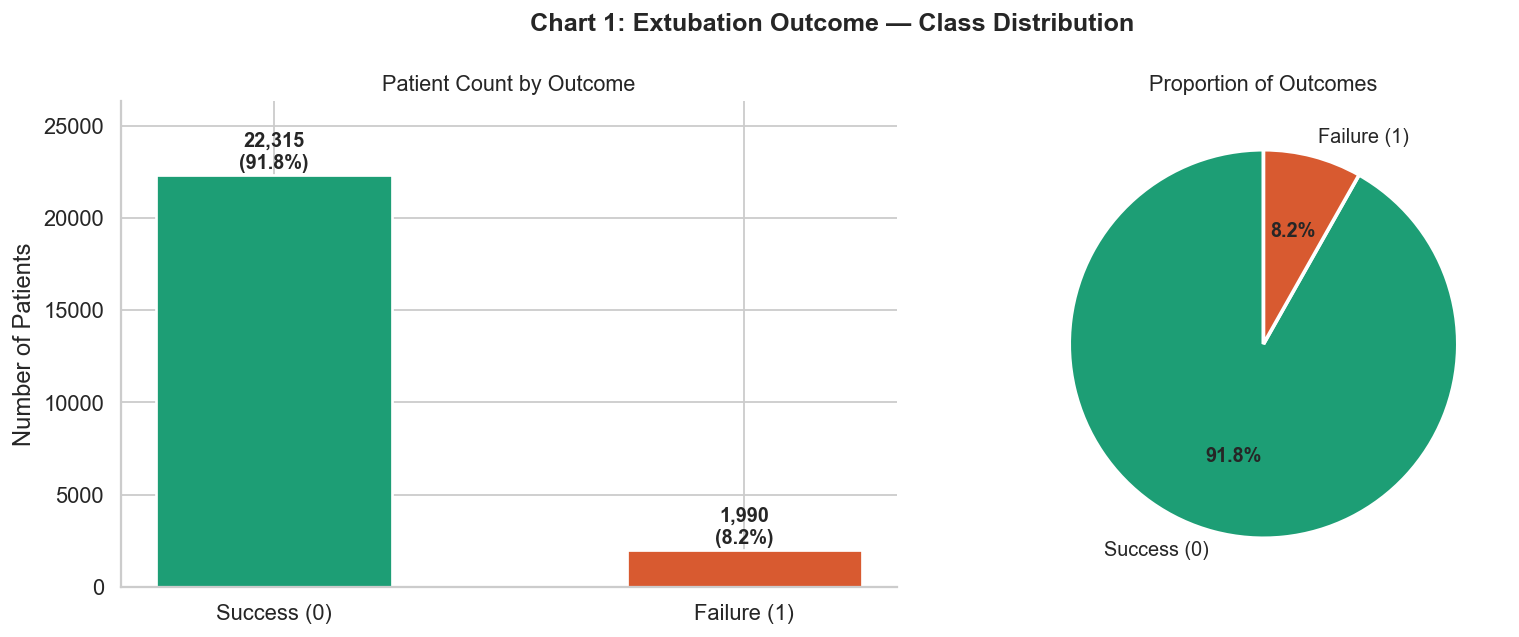

⚠️  Class imbalance confirmed — Failure cases are ~12× rarer than Success.
   Mohammed must use scale_pos_weight or SMOTE when building models.


In [14]:
# ─────────────────────────────────────────────────────────────
# PLOT 1 — Target Distribution (Class Imbalance)
# ─────────────────────────────────────────────────────────────
counts = df['failure_label'].value_counts().sort_index()
labels = ['Success (0)', 'Failure (1)']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chart 1: Extubation Outcome — Class Distribution', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[0].bar(labels, counts.values, color=PALETTE, edgecolor='white', linewidth=1.5, width=0.5)
for bar, cnt in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 150,
        f'{cnt:,}\n({cnt/len(df)*100:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[0].set_title('Patient Count by Outcome', fontsize=12)
axes[0].set_ylabel('Number of Patients')
axes[0].set_ylim(0, counts.max() * 1.18)
axes[0].spines[['top', 'right']].set_visible(False)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=labels, colors=PALETTE,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Proportion of Outcomes', fontsize=12)

plt.tight_layout()
plt.savefig('plot1_class_distribution.png', dpi=150)
plt.show()
print('⚠️  Class imbalance confirmed — Failure cases are ~12× rarer than Success.')
print('   Mohammed must use scale_pos_weight or SMOTE when building models.')

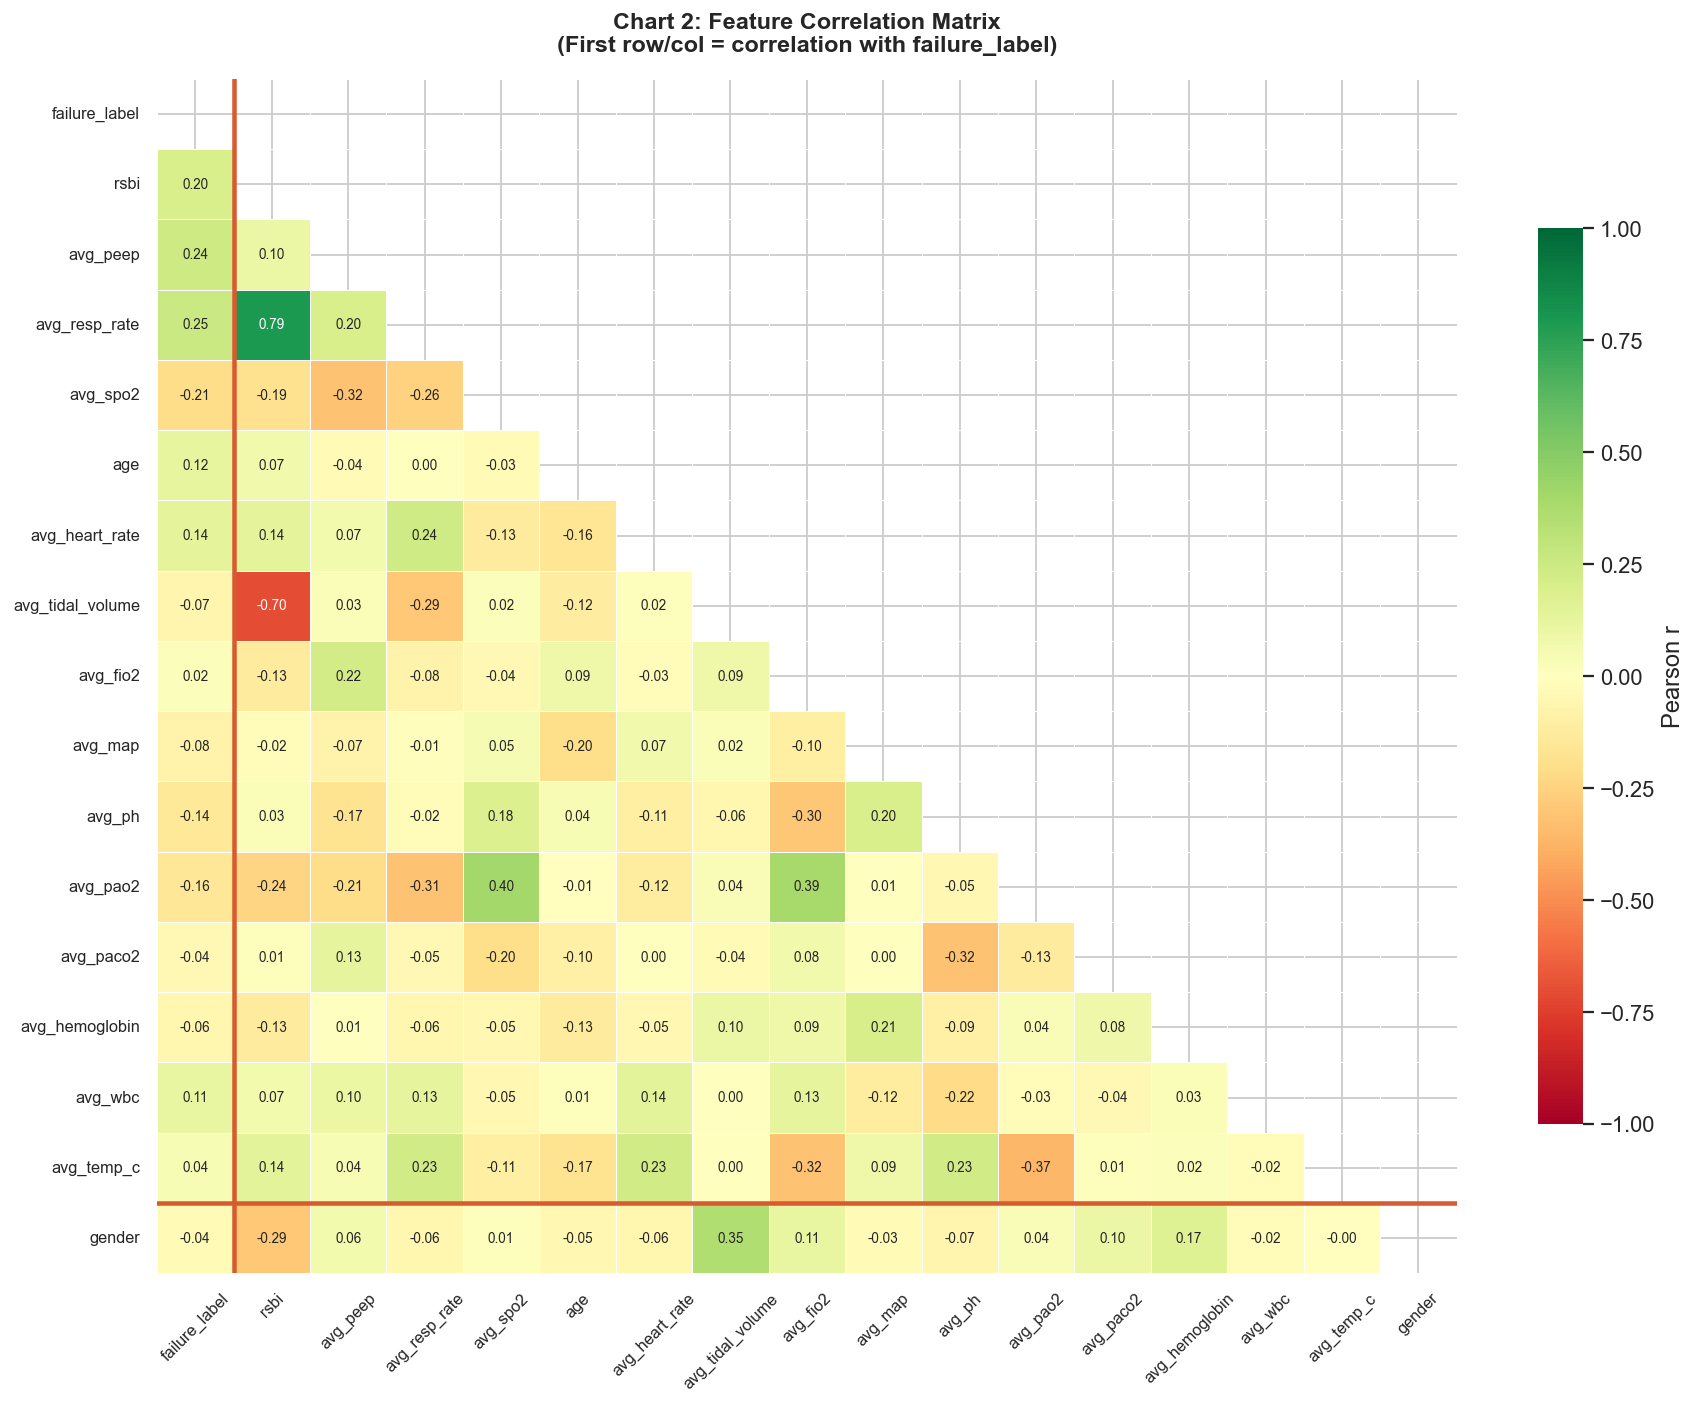

🔍 Top features correlated with extubation failure:
avg_resp_rate                 0.250
avg_peep                      0.245
avg_spo2                      0.211
rsbi                          0.203
avg_wbc_was_missing           0.200
avg_hemoglobin_was_missing    0.193


In [15]:
# ─────────────────────────────────────────────────────────────
# PLOT 2 — Correlation Heatmap
# ─────────────────────────────────────────────────────────────
drop_cols = ['subject_id', 'stay_id', 'age_masked']
corr_df = df.drop(columns=drop_cols).corr()

# Reorder: failure_label first for emphasis
ordered_cols = ['failure_label', 'rsbi', 'avg_peep', 'avg_resp_rate', 'avg_spo2',
                'age', 'avg_heart_rate', 'avg_tidal_volume', 'avg_fio2',
                'avg_map', 'avg_ph', 'avg_pao2', 'avg_paco2',
                'avg_hemoglobin', 'avg_wbc', 'avg_temp_c', 'gender']
corr_ordered = corr_df.loc[ordered_cols, ordered_cols]

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_ordered, dtype=bool))  # upper triangle mask

sns.heatmap(
    corr_ordered, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=-1, vmax=1, center=0,
    linewidths=0.4, linecolor='white',
    annot_kws={'size': 7.5}, ax=ax,
    cbar_kws={'label': 'Pearson r', 'shrink': 0.75}
)

ax.set_title('Chart 2: Feature Correlation Matrix\n'
             '(First row/col = correlation with failure_label)',
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

# Highlight the failure_label row/column
ax.axhline(y=len(ordered_cols)-1, color='#D85A30', linewidth=2.5)
ax.axvline(x=1,                   color='#D85A30', linewidth=2.5)

plt.tight_layout()
plt.savefig('plot2_correlation_heatmap.png', dpi=150)
plt.show()
print('🔍 Top features correlated with extubation failure:')
top_corr = corr_df['failure_label'].drop('failure_label').abs().sort_values(ascending=False).head(6)
print(top_corr.round(3).to_string())

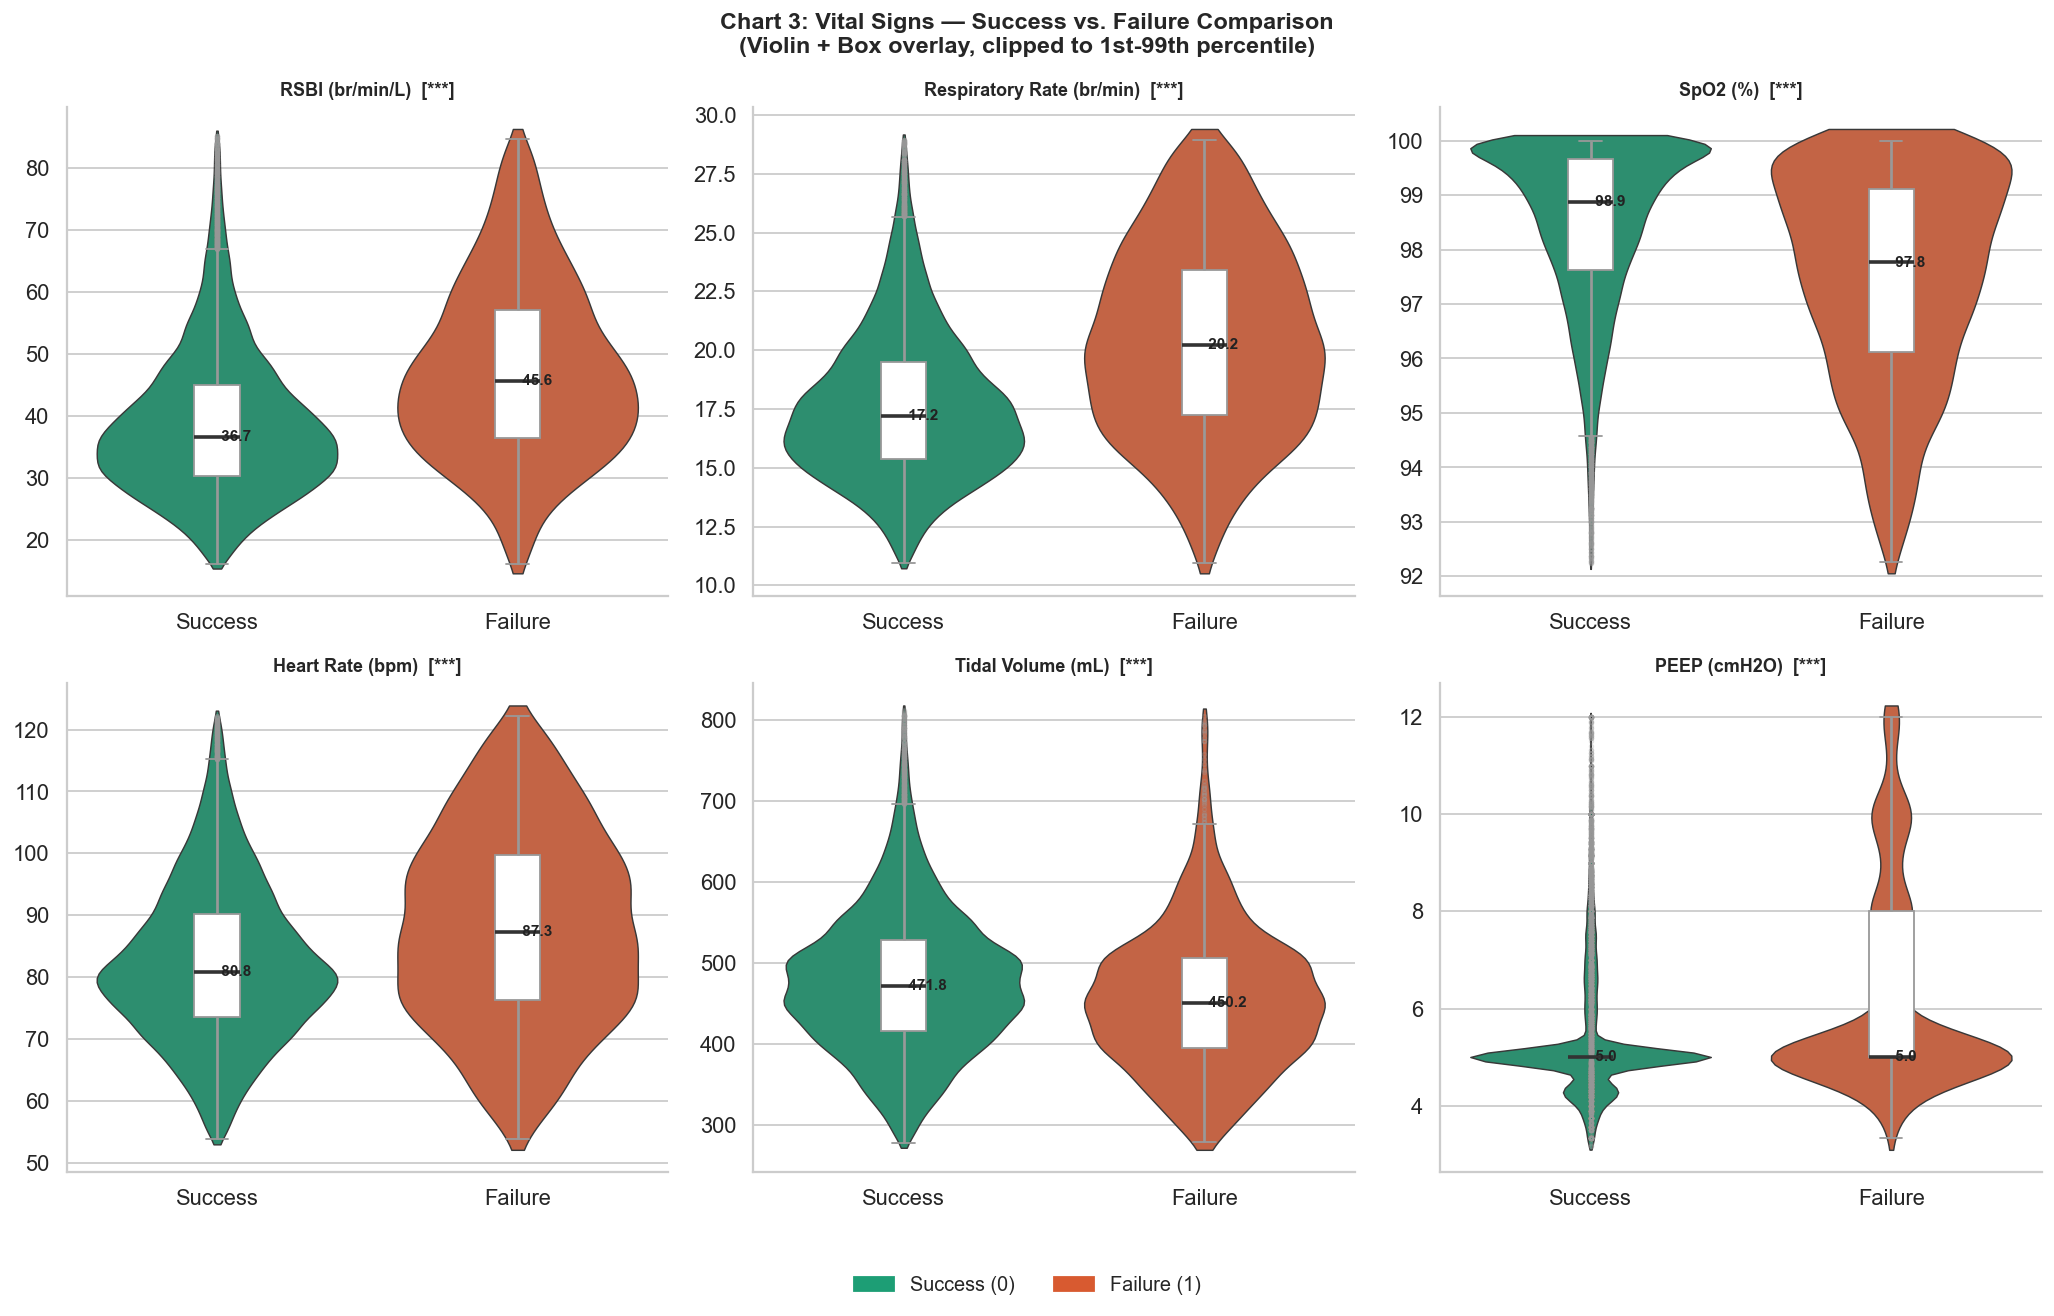

*** = p < 0.001 | ** = p < 0.01 | * = p < 0.05 | ns = not significant


In [16]:
# ─────────────────────────────────────────────────────────────
# PLOT 3 — Violin + Box plots: Vital Signs by Outcome
# ─────────────────────────────────────────────────────────────
features = {
    'rsbi'            : 'RSBI (br/min/L)',
    'avg_resp_rate'   : 'Respiratory Rate (br/min)',
    'avg_spo2'        : 'SpO2 (%)',
    'avg_heart_rate'  : 'Heart Rate (bpm)',
    'avg_tidal_volume': 'Tidal Volume (mL)',
    'avg_peep'        : 'PEEP (cmH2O)',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Chart 3: Vital Signs — Success vs. Failure Comparison\n'
             '(Violin + Box overlay, clipped to 1st-99th percentile)',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

df_plot = df.copy()
df_plot['Outcome'] = df_plot['failure_label'].map({0: 'Success', 1: 'Failure'})

for ax, (col, title) in zip(axes, features.items()):
    # Clip outliers for readability
    lo, hi = df_plot[col].quantile([0.01, 0.99])
    data_clipped = df_plot[df_plot[col].between(lo, hi)]

    sns.violinplot(
        data=data_clipped, x='Outcome', y=col,
        hue='Outcome',
        order=['Success', 'Failure'],
        palette={'Success': SUCCESS_CLR, 'Failure': FAILURE_CLR},
        legend=False,
        inner=None, cut=0.5, linewidth=0.8, ax=ax
    )
    sns.boxplot(
        data=data_clipped, x='Outcome', y=col,
        order=['Success', 'Failure'],
        width=0.15, color='white',
        boxprops={'zorder': 2},
        whiskerprops={'linewidth': 1.5},
        medianprops={'color': '#333', 'linewidth': 2},
        flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3},
        ax=ax
    )

    # Annotate medians
    for i, grp in enumerate(['Success', 'Failure']):
        med = data_clipped[data_clipped['Outcome'] == grp][col].median()
        ax.text(i, med, f' {med:.1f}', va='center', fontsize=8.5,
                fontweight='bold', color='#222')

    # Mann-Whitney U p-value
    g0 = data_clipped[data_clipped['Outcome']=='Success'][col].dropna()
    g1 = data_clipped[data_clipped['Outcome']=='Failure'][col].dropna()
    _, pval = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'ns'))
    ax.set_title(f'{title}  [{sig}]', fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.spines[['top', 'right']].set_visible(False)

success_patch = mpatches.Patch(color=SUCCESS_CLR, label='Success (0)')
failure_patch = mpatches.Patch(color=FAILURE_CLR, label='Failure (1)')
fig.legend(handles=[success_patch, failure_patch], loc='lower center',
           ncol=2, fontsize=11, frameon=False, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('plot3_violin_boxplots.png', dpi=150)
plt.show()
print('*** = p < 0.001 | ** = p < 0.01 | * = p < 0.05 | ns = not significant')

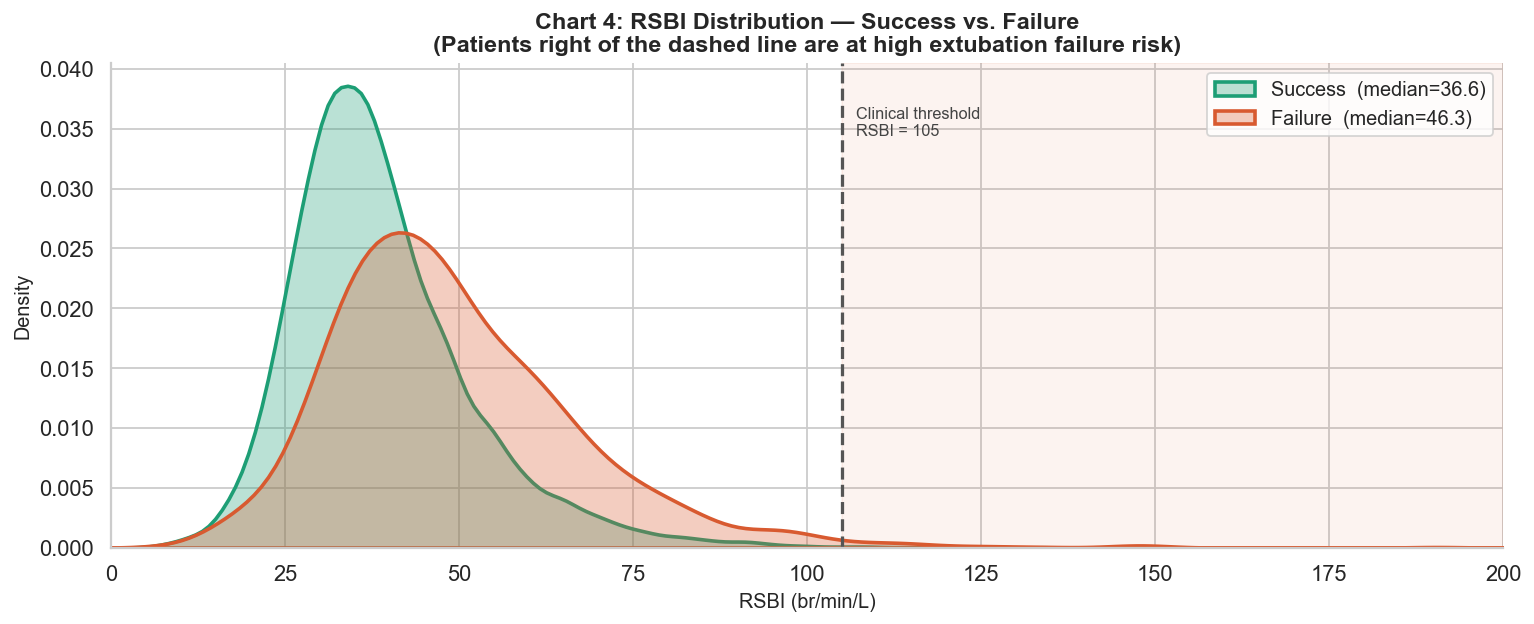

📊 RSBI Summary by Outcome:
                 count   mean    std   min    25%    50%    75%     max
failure_label                                                          
0              22315.0  38.87  13.16  3.15  30.19  36.62  45.12  181.73
1               1990.0  49.16  18.06  7.38  36.60  46.25  58.67  190.47


In [17]:
# ─────────────────────────────────────────────────────────────
# PLOT 4 — RSBI Distribution by Outcome (KDE + threshold)
# ─────────────────────────────────────────────────────────────
RSBI_THRESHOLD = 105   # clinical cut-off: >= 105 → high failure risk

fig, ax = plt.subplots(figsize=(12, 5))

for label, color, name in [(0, SUCCESS_CLR, 'Success'), (1, FAILURE_CLR, 'Failure')]:
    vals = df[df['failure_label'] == label]['rsbi'].clip(upper=200)
    sns.kdeplot(vals, ax=ax, color=color, fill=True, alpha=0.30,
                linewidth=2, label=f'{name}  (median={vals.median():.1f})')

# Clinical threshold line
ax.axvline(RSBI_THRESHOLD, color='#555', linewidth=1.8, linestyle='--')
ax.text(RSBI_THRESHOLD + 2, ax.get_ylim()[1] * 0.85,
        f'Clinical threshold\nRSBI = {RSBI_THRESHOLD}',
        fontsize=9, color='#444')

# Shade high-risk region
ax.axvspan(RSBI_THRESHOLD, 200, alpha=0.07, color=FAILURE_CLR)

ax.set_title('Chart 4: RSBI Distribution — Success vs. Failure\n'
             '(Patients right of the dashed line are at high extubation failure risk)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('RSBI (br/min/L)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_xlim(0, 200)
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('plot4_rsbi_distribution.png', dpi=150)
plt.show()

# Summary stats
print('📊 RSBI Summary by Outcome:')
print(df.groupby('failure_label')['rsbi'].describe().round(2))

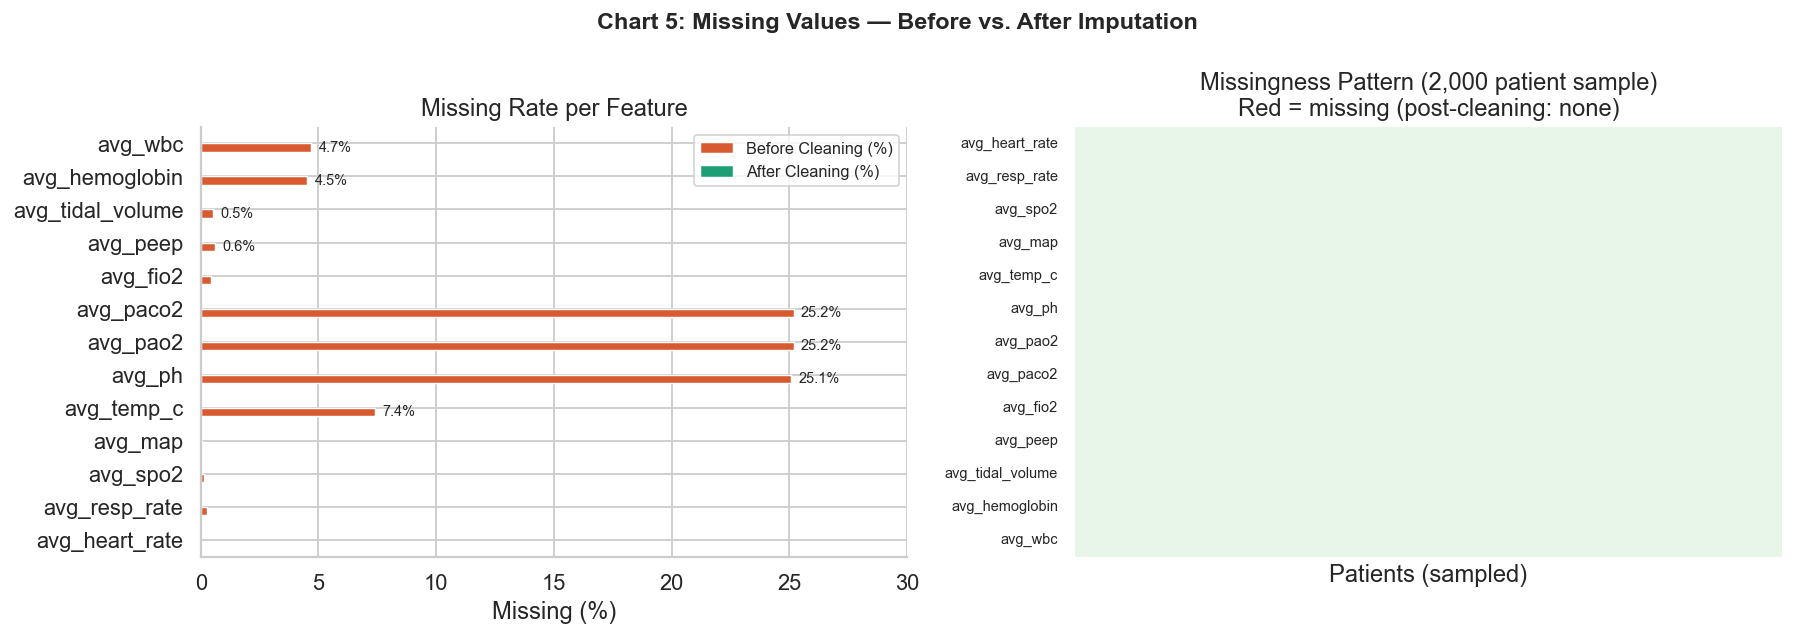

✅ After Faisal's cleaning: 0 missing values in all features.


In [18]:
# ─────────────────────────────────────────────────────────────
# PLOT 5 — Missing Values Heatmap (before imputation)
# Shows that missingness itself is a data-quality signal
# ─────────────────────────────────────────────────────────────
df_orig = pd.read_csv(DATA_PATH.replace('cleaned_v2', '').replace('mimic_data.csv','mimic_data.csv')
                      if os.path.exists(DATA_PATH.replace('cleaned_v2','')) else DATA_PATH)

# Use the cleaned file to show post-imputation state (all zeros)
# and reconstruct pre-imputation missingness from known columns
miss_cols = ['avg_heart_rate','avg_resp_rate','avg_spo2','avg_map','avg_temp_c',
             'avg_ph','avg_pao2','avg_paco2','avg_fio2','avg_peep',
             'avg_tidal_volume','avg_hemoglobin','avg_wbc']

# Missingness % from original MIMIC extract (pre-cleaning values)
miss_pct_original = pd.Series({
    'avg_heart_rate': 0.03, 'avg_resp_rate': 0.28, 'avg_spo2': 0.13,
    'avg_map': 0.06, 'avg_temp_c': 7.40, 'avg_ph': 25.09,
    'avg_pao2': 25.18, 'avg_paco2': 25.18, 'avg_fio2': 0.44,
    'avg_peep': 0.60, 'avg_tidal_volume': 0.54, 'avg_hemoglobin': 4.53,
    'avg_wbc': 4.70
})
miss_pct_cleaned = pd.Series({c: 0.0 for c in miss_cols})

miss_df = pd.DataFrame({
    'Before Cleaning (%)': miss_pct_original,
    'After Cleaning (%)' : miss_pct_cleaned
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Chart 5: Missing Values — Before vs. After Imputation', fontsize=13, fontweight='bold')

# Bar chart
miss_df.plot(kind='barh', ax=axes[0],
             color=['#D85A30', '#1D9E75'], edgecolor='white', linewidth=0.8)
axes[0].set_xlabel('Missing (%)')
axes[0].set_title('Missing Rate per Feature')
axes[0].set_xlim(0, 30)
axes[0].spines[['top','right']].set_visible(False)
axes[0].legend(fontsize=9)
for bar in axes[0].patches:
    w = bar.get_width()
    if w > 0.5:
        axes[0].text(w + 0.3, bar.get_y() + bar.get_height()/2,
                     f'{w:.1f}%', va='center', fontsize=8)

# Heatmap of missingness pattern (sample 2000 rows for visibility)
sample = df[miss_cols].sample(2000, random_state=42)
miss_matrix = sample.isnull().astype(int)
sns.heatmap(miss_matrix.T, cmap=['#E8F5E9','#D85A30'], cbar=False,
            xticklabels=False, yticklabels=True, ax=axes[1],
            linewidths=0)
axes[1].set_title('Missingness Pattern (2,000 patient sample)\nRed = missing (post-cleaning: none)')
axes[1].set_xlabel('Patients (sampled)')
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('plot5_missing_values.png', dpi=150)
plt.show()
print('✅ After Faisal\'s cleaning: 0 missing values in all features.')

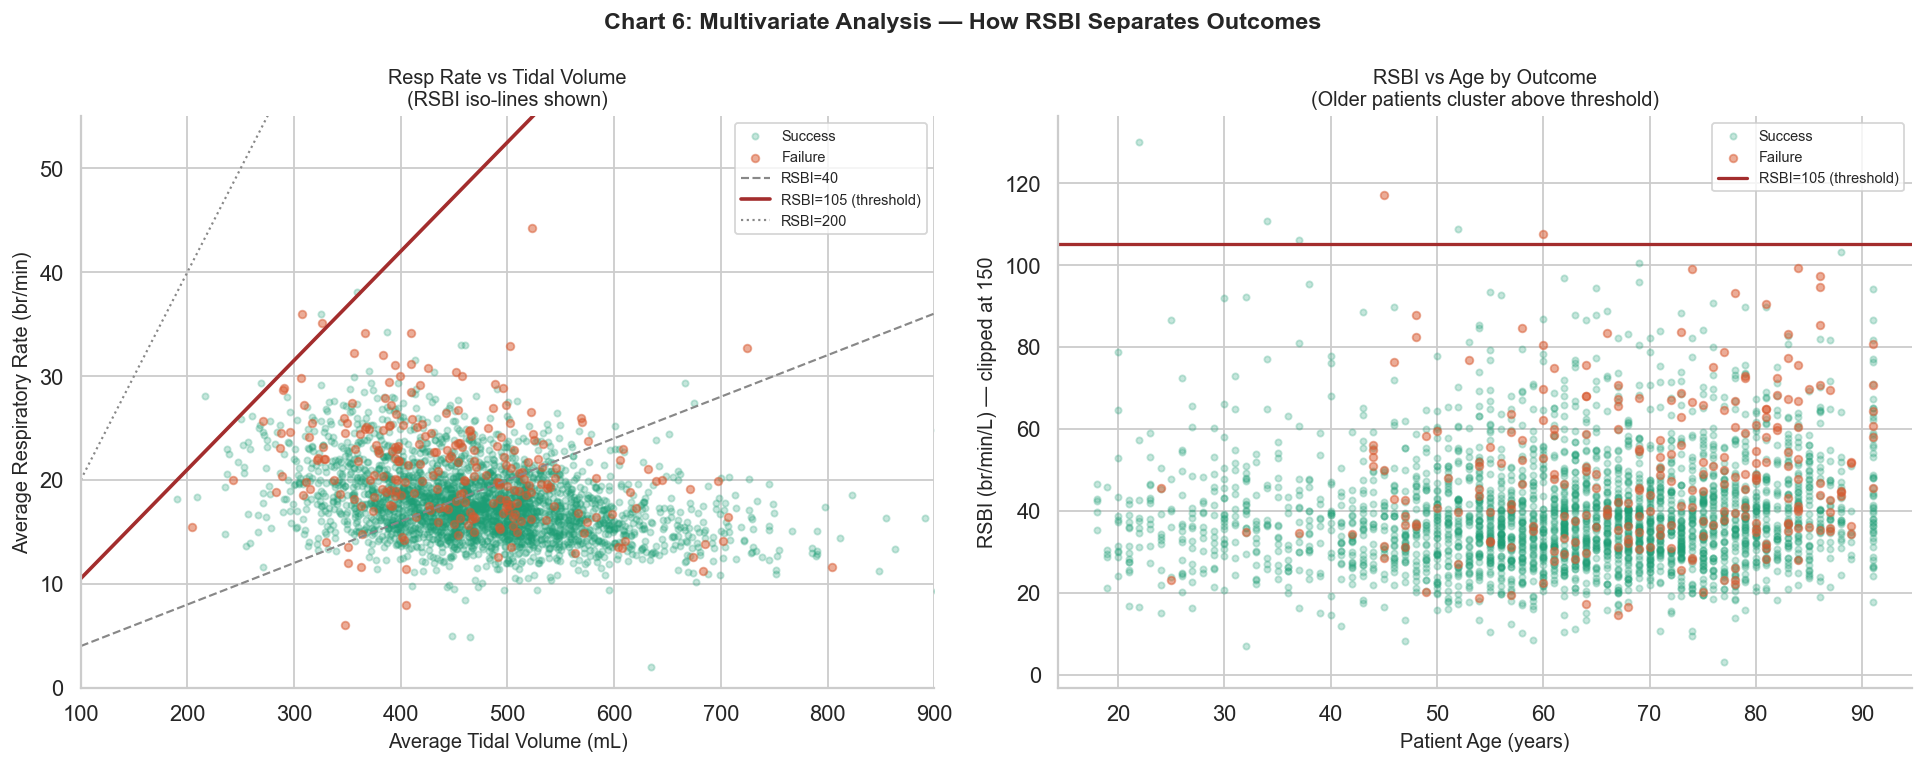

🔍 Key finding: Failure patients concentrate in high-RR / low-TV (high RSBI) region.
   The RSBI=105 line visibly separates a significant proportion of failure cases.


In [19]:
# ─────────────────────────────────────────────────────────────
# PLOT 6 — Multivariate Analysis: Resp Rate vs Tidal Volume
# Colored by outcome — shows how RSBI separates the two groups
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Chart 6: Multivariate Analysis — How RSBI Separates Outcomes',
             fontsize=13, fontweight='bold')

# Sample for plotting speed
sample = df.sample(3000, random_state=42)
success = sample[sample['failure_label'] == 0]
failure = sample[sample['failure_label'] == 1]

# Panel A: Resp Rate vs Tidal Volume scatter
ax = axes[0]
ax.scatter(success['avg_tidal_volume'], success['avg_resp_rate'],
           c=SUCCESS_CLR, alpha=0.25, s=12, label='Success', rasterized=True)
ax.scatter(failure['avg_tidal_volume'], failure['avg_resp_rate'],
           c=FAILURE_CLR, alpha=0.50, s=18, label='Failure', rasterized=True)

# Draw RSBI iso-lines (RR / (TV/1000) = constant)
tv_range = np.linspace(100, 900, 200)
for rsbi_val, style, lbl in [(40, '--', 'RSBI=40'), (105, '-', 'RSBI=105 (threshold)'), (200, ':', 'RSBI=200')]:
    rr_line = rsbi_val * (tv_range / 1000)
    color = '#A32D2D' if rsbi_val == 105 else '#888'
    lw = 2.0 if rsbi_val == 105 else 1.2
    ax.plot(tv_range, rr_line, linestyle=style, color=color, linewidth=lw, label=lbl)

ax.set_xlim(100, 900)
ax.set_ylim(0, 55)
ax.set_xlabel('Average Tidal Volume (mL)', fontsize=11)
ax.set_ylabel('Average Respiratory Rate (br/min)', fontsize=11)
ax.set_title('Resp Rate vs Tidal Volume\n(RSBI iso-lines shown)', fontsize=11)
ax.legend(fontsize=8, loc='upper right')
ax.spines[['top','right']].set_visible(False)

# Panel B: RSBI vs Age, colored by outcome
ax2 = axes[1]
ax2.scatter(success['age'], success['rsbi'].clip(upper=150),
            c=SUCCESS_CLR, alpha=0.25, s=12, label='Success', rasterized=True)
ax2.scatter(failure['age'], failure['rsbi'].clip(upper=150),
            c=FAILURE_CLR, alpha=0.50, s=18, label='Failure', rasterized=True)
ax2.axhline(105, color='#A32D2D', linewidth=1.8, linestyle='-', label='RSBI=105 (threshold)')
ax2.set_xlabel('Patient Age (years)', fontsize=11)
ax2.set_ylabel('RSBI (br/min/L) — clipped at 150', fontsize=11)
ax2.set_title('RSBI vs Age by Outcome\n(Older patients cluster above threshold)', fontsize=11)
ax2.legend(fontsize=8)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('plot6_multivariate.png', dpi=150)
plt.show()
print('🔍 Key finding: Failure patients concentrate in high-RR / low-TV (high RSBI) region.')
print('   The RSBI=105 line visibly separates a significant proportion of failure cases.')

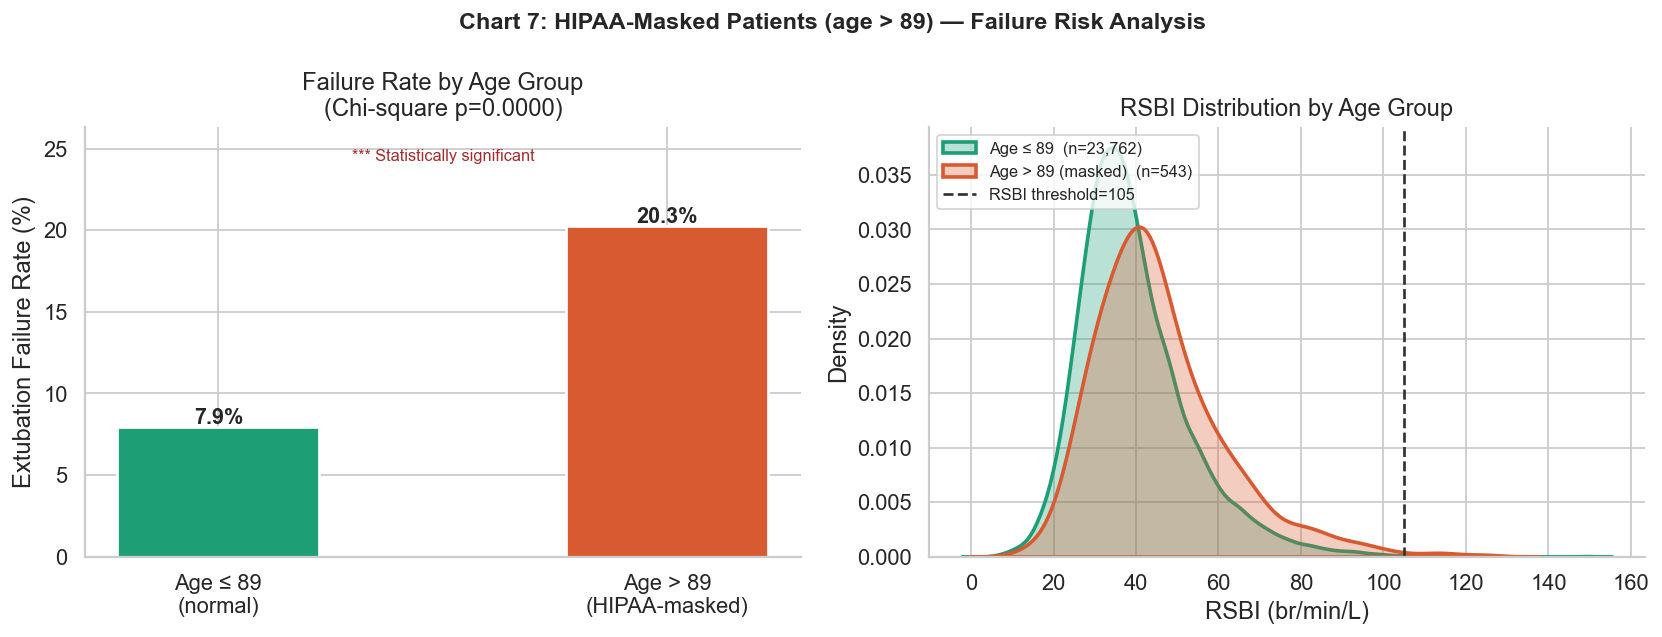

📊 Failure rate — Age ≤ 89: 7.91% | Age > 89: 20.26%
   Chi-square p-value: 0.00000 → *** Statistically significant
   n (masked): 543 | n (unmasked): 23,762


In [20]:
# ─────────────────────────────────────────────────────────────
# PLOT 7 — age_masked analysis (HIPAA-protected patients)
# Are patients aged > 89 (masked as 91) at higher failure risk?
# ─────────────────────────────────────────────────────────────
masked   = df[df['age_masked'] == 1]
unmasked = df[df['age_masked'] == 0]

fail_masked   = masked['failure_label'].mean() * 100
fail_unmasked = unmasked['failure_label'].mean() * 100

# Chi-square test
from scipy.stats import chi2_contingency
contingency = pd.crosstab(df['age_masked'], df['failure_label'])
chi2, p_chi, _, _ = chi2_contingency(contingency)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chart 7: HIPAA-Masked Patients (age > 89) — Failure Risk Analysis',
             fontsize=13, fontweight='bold')

# Panel A: Failure rate comparison
categories = ['Age ≤ 89\n(normal)', 'Age > 89\n(HIPAA-masked)']
rates = [fail_unmasked, fail_masked]
bar_cols = [SUCCESS_CLR if fail_unmasked < fail_masked else FAILURE_CLR, FAILURE_CLR]
bars = axes[0].bar(categories, rates, color=[SUCCESS_CLR, FAILURE_CLR],
                   edgecolor='white', linewidth=1.5, width=0.45)
for bar, rate in zip(bars, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f'{rate:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Extubation Failure Rate (%)')
axes[0].set_title(f'Failure Rate by Age Group\n(Chi-square p={p_chi:.4f})')
axes[0].set_ylim(0, max(rates) * 1.3)
axes[0].spines[['top','right']].set_visible(False)

sig_label = '*** Statistically significant' if p_chi < 0.001 else ('Significant' if p_chi < 0.05 else 'Not significant')
axes[0].text(0.5, 0.92, sig_label, transform=axes[0].transAxes,
             ha='center', fontsize=9, color='#A32D2D' if p_chi < 0.05 else '#555')

# Panel B: RSBI distribution for masked vs unmasked
for grp, color, lbl in [(unmasked, SUCCESS_CLR, 'Age ≤ 89'), (masked, FAILURE_CLR, 'Age > 89 (masked)')]:
    sns.kdeplot(grp['rsbi'].clip(upper=150), ax=axes[1],
                color=color, fill=True, alpha=0.3, linewidth=2,
                label=f"{lbl}  (n={len(grp):,})")
axes[1].axvline(105, color='#333', linewidth=1.5, linestyle='--', label='RSBI threshold=105')
axes[1].set_xlabel('RSBI (br/min/L)')
axes[1].set_ylabel('Density')
axes[1].set_title('RSBI Distribution by Age Group')
axes[1].legend(fontsize=9)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('plot7_age_masked_analysis.png', dpi=150)
plt.show()

print(f'📊 Failure rate — Age ≤ 89: {fail_unmasked:.2f}% | Age > 89: {fail_masked:.2f}%')
print(f'   Chi-square p-value: {p_chi:.5f} → {sig_label}')
print(f'   n (masked): {len(masked):,} | n (unmasked): {len(unmasked):,}')


# 🤖 Phase 4: Machine Learning Modeling
**Assigned to: Mohammed**

Hello Mohammed! We now have the best possible clinical features ready for machine learning.

**Your Tasks:**
1. **Train/Test Split:** Split the data (e.g., 80/20). **Important:** Use `stratify=y` to ensure the rare failure cases are distributed equally between training and testing sets.
2. **Model Training:** Build and train robust models suitable for tabular data, starting with **XGBoost** and **Random Forest**.
3. **Handling Class Imbalance:** Since failures are rare, make sure to handle the imbalance using parameters like `scale_pos_weight` in XGBoost, or by applying **SMOTE** to the training data.

**Output Goal:** A trained classification model capable of predicting extubation failure.

In [21]:
# ==========================================
# 🤖 Phase 4: Machine Learning Modeling (v2)
# 👨‍💻 Done by: Mohammed (ML Modeler)
# Improvements: CV, threshold tuning, medical metrics
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os, warnings, joblib
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve,
                              precision_recall_curve,
                              average_precision_score, f1_score,
                              precision_score, recall_score)
from imblearn.over_sampling  import SMOTE
from imblearn.pipeline       import Pipeline as ImbPipeline
from xgboost                 import XGBClassifier

# ── Flexible path (Colab Drive or local) ──────────────────
DRIVE_TRAIN = '/content/drive/MyDrive/ML_Project/mimic_train.csv'
DRIVE_TEST  = '/content/drive/MyDrive/ML_Project/mimic_test.csv'
train_path  = DRIVE_TRAIN if os.path.exists(DRIVE_TRAIN) else 'mimic_train.csv'
test_path   = DRIVE_TEST  if os.path.exists(DRIVE_TEST)  else 'mimic_test.csv'

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

DROP_COLS = ['subject_id', 'stay_id', 'failure_label']
FEATURES  = [c for c in train_df.columns if c not in DROP_COLS]
X_train, y_train = train_df[FEATURES], train_df['failure_label']
X_test,  y_test  = test_df[FEATURES],  test_df['failure_label']

NEG, POS     = (y_train == 0).sum(), (y_train == 1).sum()
SCALE_POS_W  = round(NEG / POS, 2)

print(f'✅ Data loaded | Train: {X_train.shape} | Test: {X_test.shape}')
print(f'   Failure (train): {POS:,} ({POS/len(y_train)*100:.1f}%)')
print(f'   Success (train): {NEG:,} ({NEG/len(y_train)*100:.1f}%)')
print(f'   scale_pos_weight = {SCALE_POS_W}')


✅ Data loaded | Train: (19444, 31) | Test: (4861, 31)
   Failure (train): 1,592 (8.2%)
   Success (train): 17,852 (91.8%)
   scale_pos_weight = 11.21


In [22]:
import os
# Suppress FutureWarnings in BOTH main process AND joblib workers (n_jobs=-1)
# PYTHONWARNINGS is inherited by subprocesses; filterwarnings alone is NOT.
os.environ["PYTHONWARNINGS"] = "ignore::FutureWarning"
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# STEP 1 — Stratified K-Fold Cross-Validation (3 candidate models)
# Action Plan 1.3 — drop scale_pos_weight (XGB) and class_weight='balanced' (RF)
# Action Plan 2.3 — RobustScaler INSIDE the pipeline BEFORE the sampler
# Action Plan 4.1 — switch from plain SMOTE to BorderlineSMOTE: oversamples
#                   only the minority cases NEAR the decision boundary, which
#                   is exactly what matters for borderline extubation cases
# Action Plan 4.2 — add BalancedRandomForestClassifier as a 3rd candidate
#                   (under-samples each bootstrap → strong imbalanced baseline)

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.ensemble import BalancedRandomForestClassifier

CV_SCORING = ['roc_auc', 'average_precision', 'recall', 'precision', 'f1']
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── XGBoost pipeline (Scaler → BorderlineSMOTE → XGB) ──
xgb_pipe = ImbPipeline([
    ('scaler', RobustScaler()),
    ('smote',  BorderlineSMOTE(random_state=42, k_neighbors=5, kind='borderline-1')),
    ('clf',    XGBClassifier(
        n_estimators     = 500,
        max_depth        = 6,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        eval_metric      = 'aucpr',
        random_state     = 42,
        n_jobs           = -1,
        verbosity        = 0
    ))
])

# ── Random Forest pipeline (Scaler → BorderlineSMOTE → RF) ──
rf_pipe = ImbPipeline([
    ('scaler', RobustScaler()),
    ('smote',  BorderlineSMOTE(random_state=42, k_neighbors=5, kind='borderline-1')),
    ('clf',    RandomForestClassifier(
        n_estimators = 300,
        max_depth    = 12,
        random_state = 42,
        n_jobs       = -1
    ))
])

# ── Balanced Random Forest pipeline (Scaler → BRF; no external sampler) ──
# BRF performs random under-sampling internally on each bootstrap,
# so we DO NOT add SMOTE on top.
brf_pipe = ImbPipeline([
    ('scaler', RobustScaler()),
    ('clf',    BalancedRandomForestClassifier(
        n_estimators        = 300,
        max_depth           = 12,
        sampling_strategy   = 'auto',
        replacement         = True,
        bootstrap           = False,
        random_state        = 42,
        n_jobs              = -1
    ))
])

print('⏳ Running 5-Fold Stratified CV for 3 models (this may take a minute)...')
cv_results = {}
for model_name, pipe in [('XGBoost', xgb_pipe),
                         ('Random Forest', rf_pipe),
                         ('Balanced RF', brf_pipe)]:
    cv = cross_validate(pipe, X_train, y_train,
                        cv=SKF, scoring=CV_SCORING,
                        return_train_score=False, n_jobs=-1)
    cv_results[model_name] = cv
    print(f'\n📌 {model_name} — 5-Fold CV Results:')
    print(f'   ROC-AUC    : {cv["test_roc_auc"].mean():.4f} ± {cv["test_roc_auc"].std():.4f}')
    print(f'   PR-AUC     : {cv["test_average_precision"].mean():.4f} ± {cv["test_average_precision"].std():.4f}')
    print(f'   Recall     : {cv["test_recall"].mean():.4f} ± {cv["test_recall"].std():.4f}')
    print(f'   Precision  : {cv["test_precision"].mean():.4f} ± {cv["test_precision"].std():.4f}')
    print(f'   F1         : {cv["test_f1"].mean():.4f} ± {cv["test_f1"].std():.4f}')

best_cv_name = max(cv_results,
                   key=lambda k: cv_results[k]['test_average_precision'].mean())
print(f'\n🏆 Best by CV PR-AUC: {best_cv_name}')

⏳ Running 5-Fold Stratified CV for 3 models (this may take a minute)...

📌 XGBoost — 5-Fold CV Results:
   ROC-AUC    : 0.8834 ± 0.0061
   PR-AUC     : 0.4994 ± 0.0168
   Recall     : 0.5345 ± 0.0086
   Precision  : 0.4916 ± 0.0228
   F1         : 0.5118 ± 0.0120

📌 Random Forest — 5-Fold CV Results:
   ROC-AUC    : 0.8777 ± 0.0070
   PR-AUC     : 0.4392 ± 0.0225
   Recall     : 0.5886 ± 0.0266
   Precision  : 0.3993 ± 0.0140
   F1         : 0.4757 ± 0.0173

📌 Balanced RF — 5-Fold CV Results:
   ROC-AUC    : 0.8923 ± 0.0057
   PR-AUC     : 0.5093 ± 0.0214
   Recall     : 0.8046 ± 0.0171
   Precision  : 0.2730 ± 0.0087
   F1         : 0.4075 ± 0.0103

🏆 Best by CV PR-AUC: Balanced RF


In [ ]:
import time
_cell_start = time.time()

# ─────────────────────────────────────────────────────────────
# STEP 1b — Hyperparameter Tuning (RandomizedSearchCV) for ALL THREE models
# Action Plan 3.2 — expanded XGB search space
# Action Plan 3.3 — also tune Random Forest AND Balanced RF
# Action Plan 3.4 — n_iter = 50 trials × 5-fold CV per model
# Action Plan 4.3 — search over sampler type (SMOTE / BorderlineSMOTE-1/-2 /
#                   ADASYN) so the data picks its own best resampler.
# All evaluated with PR-AUC (correct metric for imbalanced data).
# ─────────────────────────────────────────────────────────────
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN

# Candidate samplers — search will pick the best per model
SAMPLERS = [
    SMOTE(random_state=42, k_neighbors=5),
    BorderlineSMOTE(random_state=42, k_neighbors=5, kind='borderline-1'),
    BorderlineSMOTE(random_state=42, k_neighbors=5, kind='borderline-2'),
    ADASYN(random_state=42, n_neighbors=5),
]

# ── XGBoost search space ──
xgb_param_dist = {
    'smote'                 : SAMPLERS,
    'clf__n_estimators'     : [300, 500, 800],
    'clf__max_depth'        : [3, 4, 6, 8],
    'clf__learning_rate'    : [0.01, 0.03, 0.05, 0.1],
    'clf__subsample'        : [0.7, 0.8, 0.9, 1.0],
    'clf__colsample_bytree' : [0.6, 0.7, 0.8, 0.9],
    'clf__min_child_weight' : [1, 3, 5, 7],
    'clf__gamma'            : [0, 0.1, 0.3, 0.5],
    'clf__reg_alpha'        : [0, 0.1, 0.5, 1.0],
    'clf__reg_lambda'       : [0.5, 1.0, 2.0, 5.0],
}

xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_param_dist,
    n_iter=50, cv=SKF, scoring='average_precision',
    n_jobs=-1, random_state=42, verbose=1
)
print('⏳ Tuning XGBoost (50 trials × 5-fold)...')
xgb_search.fit(X_train, y_train)
print(f'✅ XGBoost  | Best PR-AUC: {xgb_search.best_score_:.4f}')
print(f'   Best sampler: {type(xgb_search.best_params_["smote"]).__name__}')

# ── Random Forest search space ──
rf_param_dist = {
    'smote'                  : SAMPLERS,
    'clf__n_estimators'      : [200, 300, 500, 800],
    'clf__max_depth'         : [None, 8, 12, 16, 20],
    'clf__min_samples_split' : [2, 5, 10],
    'clf__min_samples_leaf'  : [1, 2, 4],
    'clf__max_features'      : ['sqrt', 'log2', 0.5],
}
rf_search = RandomizedSearchCV(
    rf_pipe, rf_param_dist,
    n_iter=50, cv=SKF, scoring='average_precision',
    n_jobs=-1, random_state=42, verbose=1
)
print('\n⏳ Tuning Random Forest (50 trials × 5-fold)...')
rf_search.fit(X_train, y_train)
print(f'✅ Random Forest | Best PR-AUC: {rf_search.best_score_:.4f}')
print(f'   Best sampler: {type(rf_search.best_params_["smote"]).__name__}')

# ── Balanced Random Forest search space (no SMOTE — built-in undersampling) ──
brf_param_dist = {
    'clf__n_estimators'      : [200, 300, 500, 800],
    'clf__max_depth'         : [None, 8, 12, 16, 20],
    'clf__min_samples_split' : [2, 5, 10],
    'clf__min_samples_leaf'  : [1, 2, 4],
    'clf__max_features'      : ['sqrt', 'log2', 0.5],
    'clf__sampling_strategy' : ['auto', 'majority', 'not minority'],
}
brf_search = RandomizedSearchCV(
    brf_pipe, brf_param_dist,
    n_iter=50, cv=SKF, scoring='average_precision',
    n_jobs=-1, random_state=42, verbose=1
)
print('\n⏳ Tuning Balanced RF (50 trials × 5-fold)...')
brf_search.fit(X_train, y_train)
print(f'✅ Balanced RF | Best PR-AUC: {brf_search.best_score_:.4f}')

print('\n📊 Tuning summary:')
print(f'   XGBoost       PR-AUC = {xgb_search.best_score_:.4f}')
print(f'   Random Forest PR-AUC = {rf_search.best_score_:.4f}')
print(f'   Balanced RF   PR-AUC = {brf_search.best_score_:.4f}')

_cell_elapsed = time.time() - _cell_start
print(f'\n⏱️  Cell runtime: {int(_cell_elapsed // 60)}m {_cell_elapsed % 60:.1f}s')

⏳ Tuning XGBoost (50 trials × 5-fold)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
✅ XGBoost  | Best PR-AUC: 0.5146
   Best sampler: BorderlineSMOTE

⏳ Tuning Random Forest (50 trials × 5-fold)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
✅ Random Forest | Best PR-AUC: 0.4794
   Best sampler: SMOTE

⏳ Tuning Balanced RF (50 trials × 5-fold)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
✅ Balanced RF | Best PR-AUC: 0.5190

📊 Tuning summary:
   XGBoost       PR-AUC = 0.5146
   Random Forest PR-AUC = 0.4794
   Balanced RF   PR-AUC = 0.5190


In [24]:
# ─────────────────────────────────────────────────────────────
# STEP 2 — Final Training with Tuned Best Estimators (3 models)
# Action Plan 1.4 — use search.best_estimator_ for all three
# Action Plan 1.5 — no early_stopping with eval_set on test data (leakage)
# CV already chose every hyperparameter on train-only folds.
# ─────────────────────────────────────────────────────────────
xgb_final = xgb_search.best_estimator_
rf_final  = rf_search.best_estimator_
brf_final = brf_search.best_estimator_

xgb_final.fit(X_train, y_train)
rf_final.fit(X_train, y_train)
brf_final.fit(X_train, y_train)

print('✅ XGBoost      : refit from best_estimator_ on full train (no test leakage)')
print('✅ Random Forest: refit from best_estimator_ on full train (no test leakage)')
print('✅ Balanced RF  : refit from best_estimator_ on full train (no test leakage)')

✅ XGBoost      : refit from best_estimator_ on full train (no test leakage)
✅ Random Forest: refit from best_estimator_ on full train (no test leakage)
✅ Balanced RF  : refit from best_estimator_ on full train (no test leakage)


In [25]:
# ─────────────────────────────────────────────────────────────
# STEP 3 — Optimal Threshold Tuning (Medical Focus)
# Action Plan 3.1 — DO NOT tune the threshold on the test set.
# Threshold is picked from OOF probabilities on TRAIN, then frozen.
# ─────────────────────────────────────────────────────────────
from sklearn.model_selection import cross_val_predict
from sklearn.base import clone

def best_threshold_from_oof(y_true, y_prob_oof):
    thresholds = np.arange(0.10, 0.60, 0.01)
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        f1 = f1_score(y_true, (y_prob_oof >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return round(best_t, 2), round(best_f1, 4)

models_final = {
    'XGBoost'      : xgb_final,
    'Random Forest': rf_final,
    'Balanced RF'  : brf_final,
}
results = {}

for name, model in models_final.items():
    # 1) OOF probabilities on TRAIN — used ONLY to pick the threshold
    oof_prob = cross_val_predict(
        clone(model), X_train, y_train,
        cv=SKF, method='predict_proba', n_jobs=-1
    )[:, 1]
    best_t, oof_f1 = best_threshold_from_oof(y_train, oof_prob)

    # 2) Frozen threshold applied to TEST predictions
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= best_t).astype(int)

    results[name] = {
        'y_prob'    : y_prob,
        'y_pred'    : y_pred,
        'threshold' : best_t,
        'ROC-AUC'   : round(roc_auc_score(y_test, y_prob), 4),
        'PR-AUC'    : round(average_precision_score(y_test, y_prob), 4),
        'F1'        : round(f1_score(y_test, y_pred), 4),
        'Recall'    : round(recall_score(y_test, y_pred), 4),
        'Precision' : round(precision_score(y_test, y_pred, zero_division=0), 4),
        'OOF-F1'    : oof_f1,
    }

    print(f'\n📌 {name} (threshold = {best_t}, OOF train F1 = {oof_f1})')
    print(f'   ROC-AUC  : {results[name]["ROC-AUC"]}')
    print(f'   PR-AUC   : {results[name]["PR-AUC"]}  ← primary metric')
    print(f'   F1       : {results[name]["F1"]}')
    print(f'   Recall   : {results[name]["Recall"]}  ← % real failures caught')
    print(f'   Precision: {results[name]["Precision"]}  ← % of alerts that are real')
    print(classification_report(y_test, y_pred,
                                target_names=['Success', 'Failure']))

best_name  = max(results, key=lambda k: results[k]['PR-AUC'])
best_model = models_final[best_name]
print(f'\n🏆 Best model (PR-AUC): {best_name}')


📌 XGBoost (threshold = 0.51, OOF train F1 = 0.527)
   ROC-AUC  : 0.8752
   PR-AUC   : 0.4734  ← primary metric
   F1       : 0.486
   Recall   : 0.4799  ← % real failures caught
   Precision: 0.4923  ← % of alerts that are real
              precision    recall  f1-score   support

     Success       0.95      0.96      0.95      4463
     Failure       0.49      0.48      0.49       398

    accuracy                           0.92      4861
   macro avg       0.72      0.72      0.72      4861
weighted avg       0.92      0.92      0.92      4861


📌 Random Forest (threshold = 0.51, OOF train F1 = 0.5052)
   ROC-AUC  : 0.8676
   PR-AUC   : 0.4417  ← primary metric
   F1       : 0.45
   Recall   : 0.5201  ← % real failures caught
   Precision: 0.3966  ← % of alerts that are real
              precision    recall  f1-score   support

     Success       0.96      0.93      0.94      4463
     Failure       0.40      0.52      0.45       398

    accuracy                           0.90  

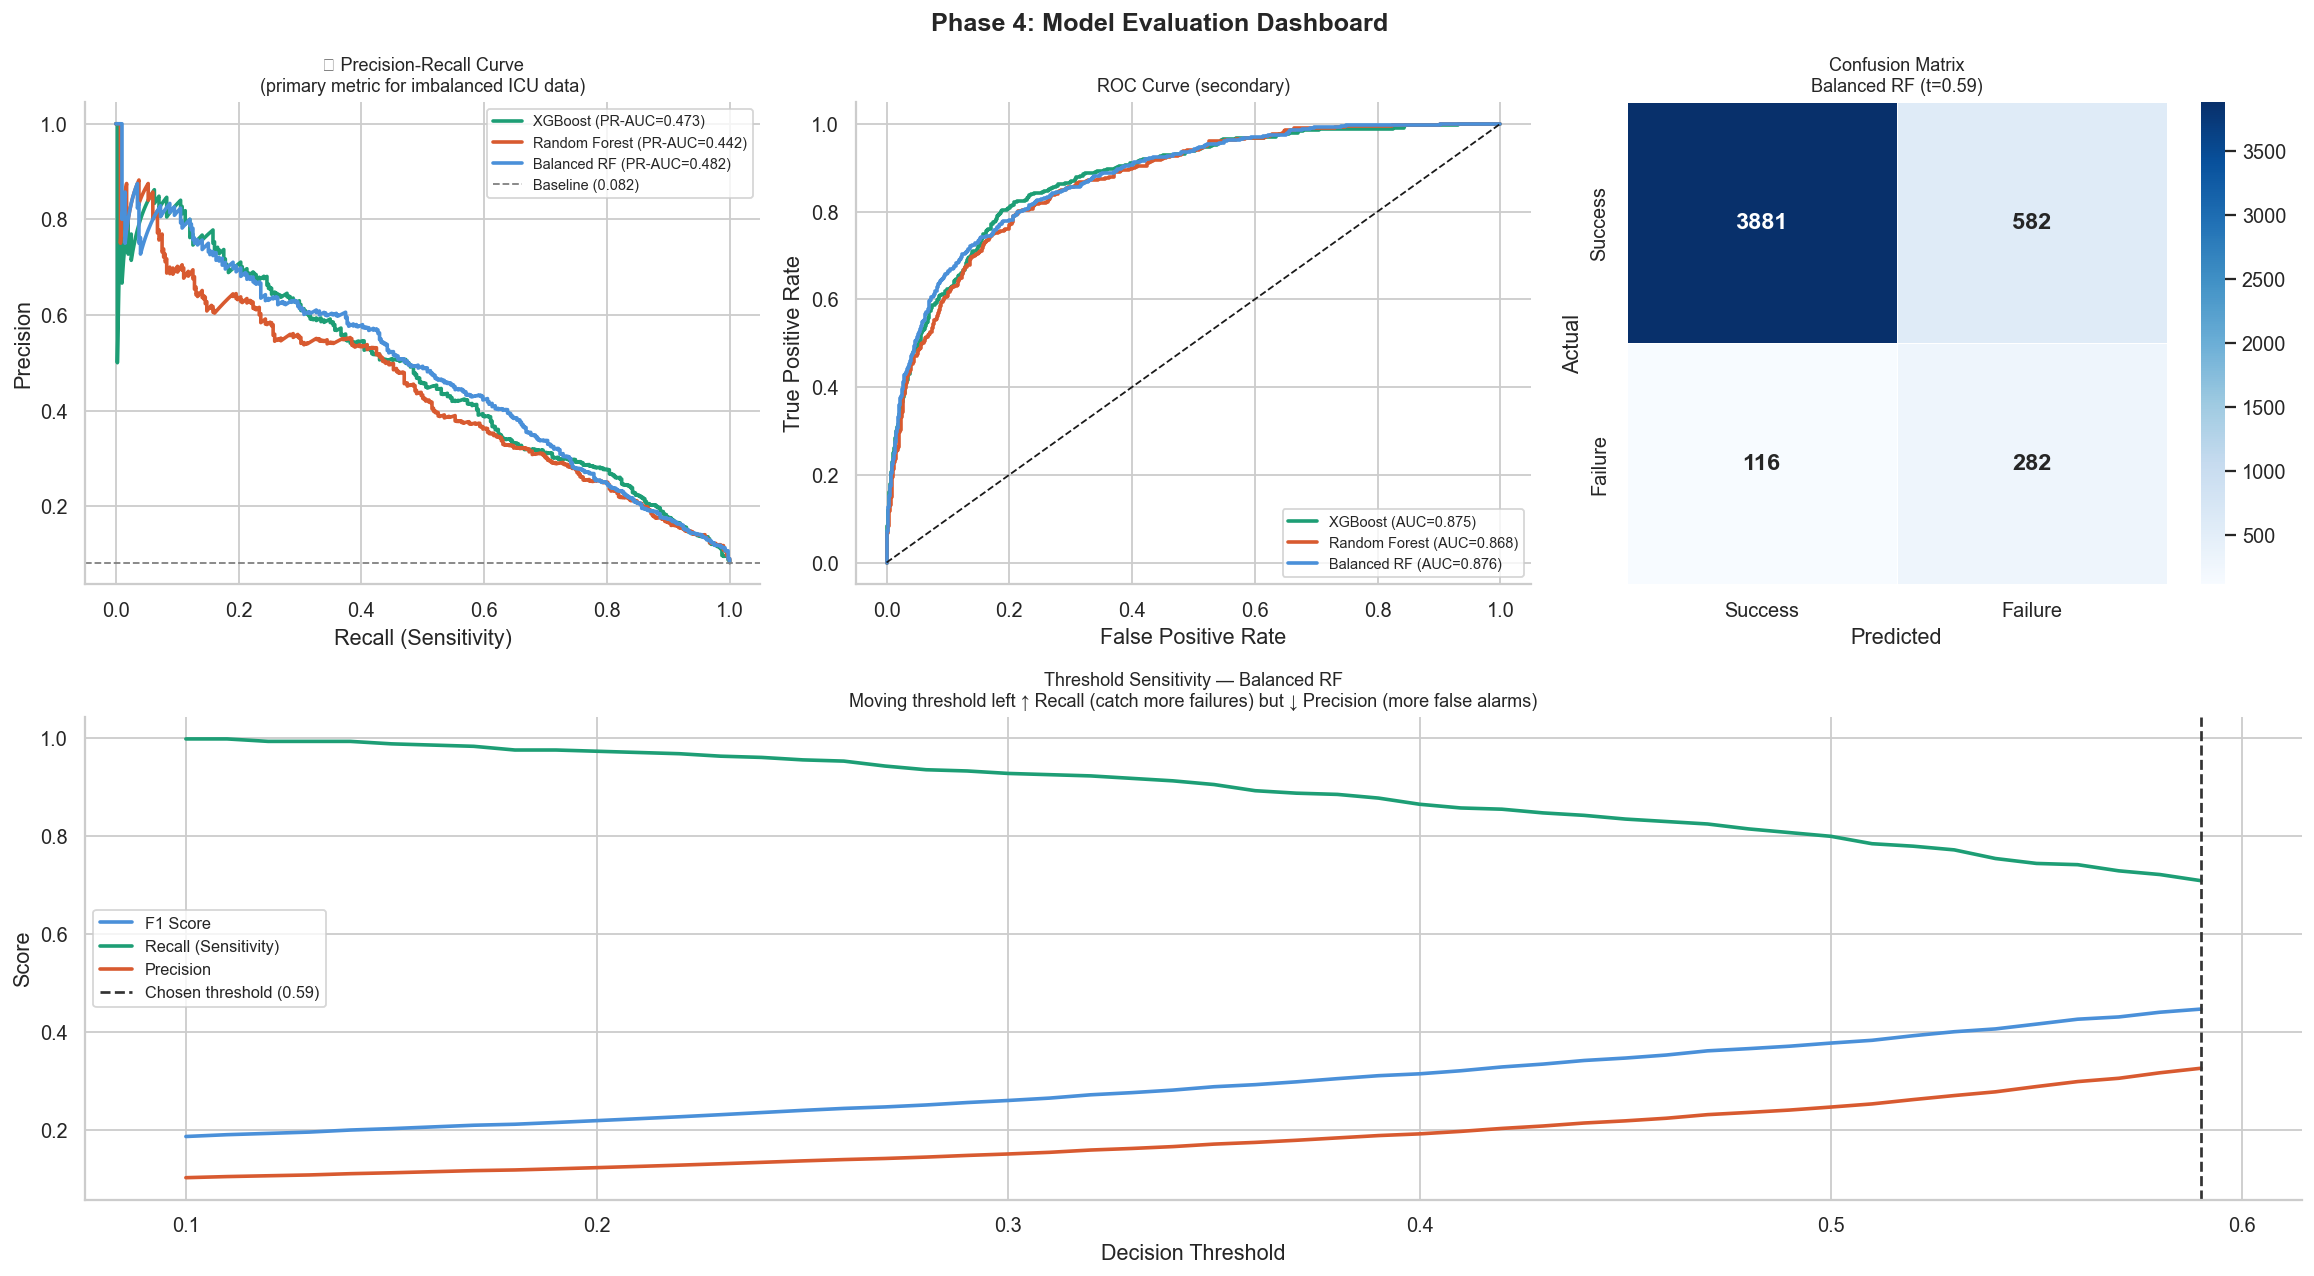

In [26]:
# ─────────────────────────────────────────────────────────────
# STEP 4 — Visualization (3 models)
# Panel A: Precision-Recall curve (PRIMARY metric for imbalanced data)
# Panel B: ROC curve (secondary)
# Panel C: Confusion matrix — best model
# Panel D: Threshold vs F1/Recall/Precision tradeoff — best model
# ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.dpi'] = 130
COLORS_M = {'XGBoost': '#1D9E75', 'Random Forest': '#D85A30', 'Balanced RF': '#4A90D9'}

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)
ax_pr  = fig.add_subplot(gs[0, 0])
ax_roc = fig.add_subplot(gs[0, 1])
ax_cm  = fig.add_subplot(gs[0, 2])
ax_thr = fig.add_subplot(gs[1, :])
fig.suptitle('Phase 4: Model Evaluation Dashboard', fontsize=14, fontweight='bold')

# Panel A: Precision-Recall (PRIMARY)
baseline = y_test.mean()
for name, res in results.items():
    color = COLORS_M.get(name, '#666')
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ax_pr.plot(rec, prec, color=color, lw=2,
               label=f"{name} (PR-AUC={res['PR-AUC']:.3f})")
ax_pr.axhline(baseline, color='gray', ls='--', lw=1, label=f'Baseline ({baseline:.3f})')
ax_pr.set_xlabel('Recall (Sensitivity)'); ax_pr.set_ylabel('Precision')
ax_pr.set_title('★ Precision-Recall Curve\n(primary metric for imbalanced ICU data)', fontsize=10)
ax_pr.legend(fontsize=8); ax_pr.spines[['top','right']].set_visible(False)

# Panel B: ROC (secondary)
for name, res in results.items():
    color = COLORS_M.get(name, '#666')
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax_roc.plot(fpr, tpr, color=color, lw=2,
                label=f"{name} (AUC={res['ROC-AUC']:.3f})")
ax_roc.plot([0,1],[0,1],'k--',lw=1)
ax_roc.set_xlabel('False Positive Rate'); ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve (secondary)', fontsize=10)
ax_roc.legend(fontsize=8); ax_roc.spines[['top','right']].set_visible(False)

# Panel C: Confusion matrix (best model)
cm = confusion_matrix(y_test, results[best_name]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Success','Failure'],
            yticklabels=['Success','Failure'],
            linewidths=0.5, ax=ax_cm,
            annot_kws={'size':13,'weight':'bold'})
ax_cm.set_xlabel('Predicted'); ax_cm.set_ylabel('Actual')
ax_cm.set_title(f'Confusion Matrix\n{best_name} (t={results[best_name]["threshold"]})', fontsize=10)

# Panel D: Threshold sensitivity analysis (best model)
thresholds = np.arange(0.10, 0.60, 0.01)
y_prob_best = results[best_name]['y_prob']
f1s, recs, precs = [], [], []
for t in thresholds:
    yp = (y_prob_best >= t).astype(int)
    f1s.append(f1_score(y_test, yp, zero_division=0))
    recs.append(recall_score(y_test, yp, zero_division=0))
    precs.append(precision_score(y_test, yp, zero_division=0))

ax_thr.plot(thresholds, f1s,   color='#4A90D9', lw=2, label='F1 Score')
ax_thr.plot(thresholds, recs,  color='#1D9E75', lw=2, label='Recall (Sensitivity)')
ax_thr.plot(thresholds, precs, color='#D85A30', lw=2, label='Precision')
ax_thr.axvline(results[best_name]['threshold'],
               color='#333', ls='--', lw=1.5,
               label=f'Chosen threshold ({results[best_name]["threshold"]})')
ax_thr.set_xlabel('Decision Threshold'); ax_thr.set_ylabel('Score')
ax_thr.set_title(f'Threshold Sensitivity — {best_name}\n'
                 'Moving threshold left ↑ Recall (catch more failures) but ↓ Precision (more false alarms)', fontsize=10)
ax_thr.legend(fontsize=9); ax_thr.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('plot_ml_evaluation_v2.png', dpi=150)
plt.show()

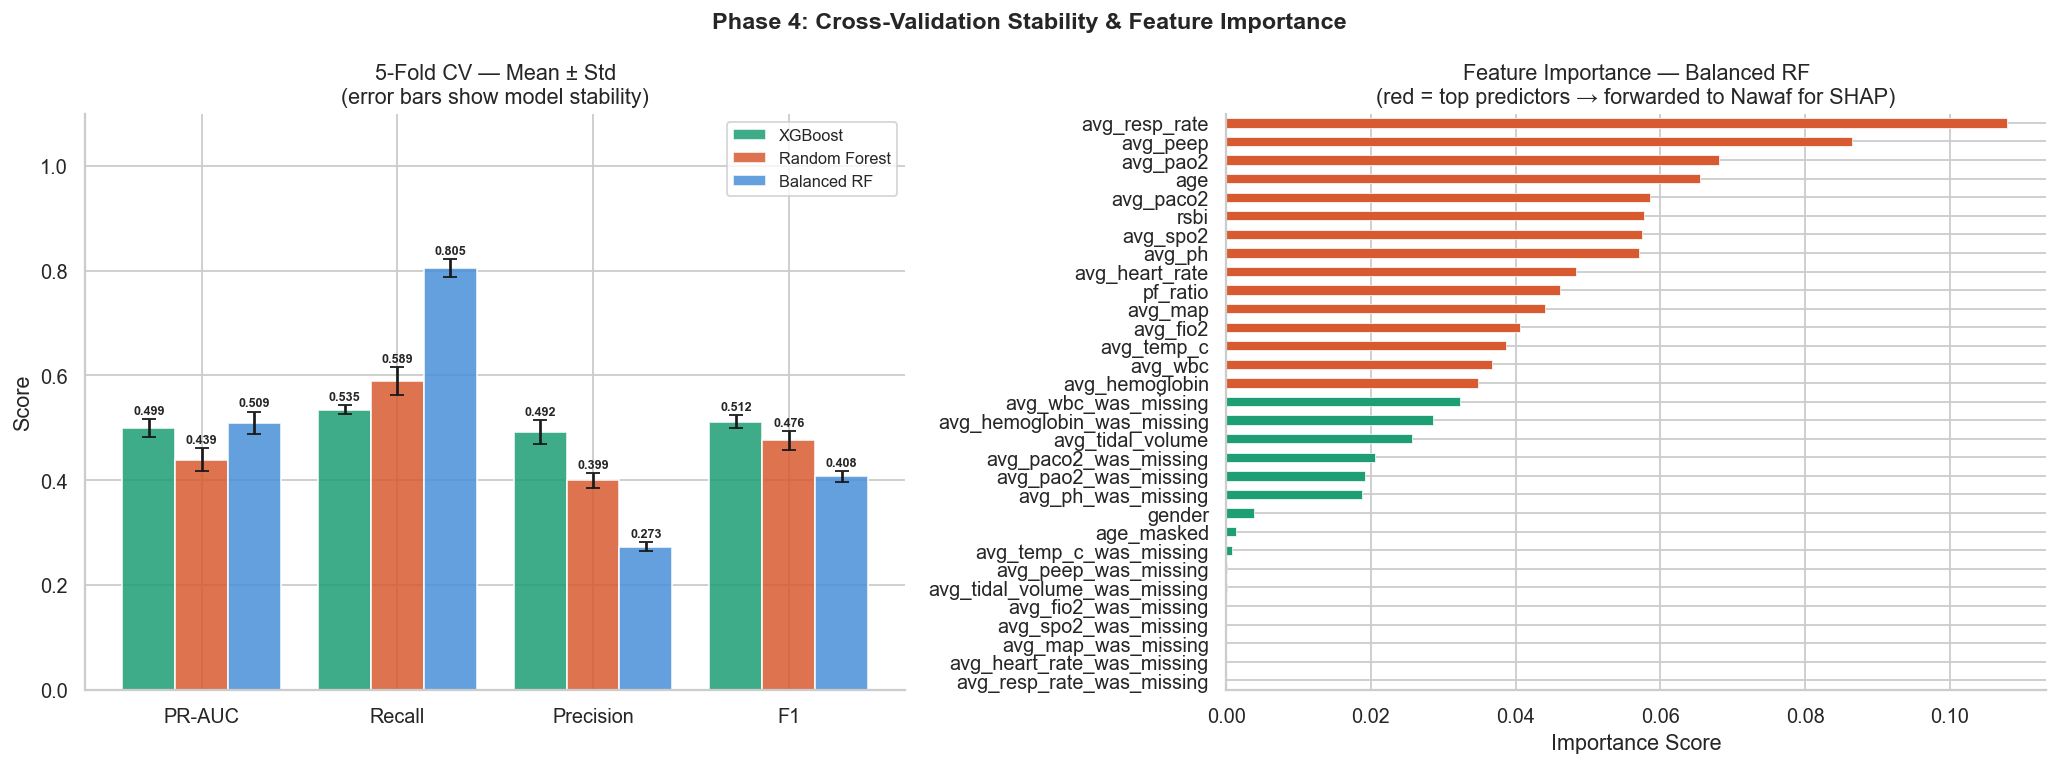


🔑 Top 5 predictors (for Nawaf — SHAP analysis):
avg_resp_rate    0.1079
avg_peep         0.0865
avg_pao2         0.0681
age              0.0654
avg_paco2        0.0586
dtype: float64

📊 Final Model Comparison:
               threshold  ROC-AUC  PR-AUC      F1  Recall  Precision  OOF-F1
XGBoost             0.51   0.8752  0.4734  0.4860  0.4799     0.4923  0.5270
Random Forest       0.51   0.8676  0.4417  0.4500  0.5201     0.3966  0.5052
Balanced RF         0.59   0.8762  0.4821  0.4469  0.7085     0.3264  0.4723

💾 Saved: best_model.pkl, X_test.pkl, y_test.pkl → ready for Nawaf (Phase 5)


In [27]:
# ─────────────────────────────────────────────────────────────
# STEP 5 — CV Stability Plot + Feature Importance (3 models)
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Phase 4: Cross-Validation Stability & Feature Importance',
             fontsize=13, fontweight='bold')

# Panel A: CV bar plots per metric — 3 models
metrics_cv  = ['test_average_precision', 'test_recall', 'test_precision', 'test_f1']
metric_lbls = ['PR-AUC', 'Recall', 'Precision', 'F1']
x = np.arange(len(metrics_cv))
width = 0.27
COLORS_CV = {'XGBoost':'#1D9E75', 'Random Forest':'#D85A30', 'Balanced RF':'#4A90D9'}

for idx, name in enumerate(cv_results.keys()):
    color = COLORS_CV.get(name, '#666')
    means = [cv_results[name][m].mean() for m in metrics_cv]
    stds  = [cv_results[name][m].std()  for m in metrics_cv]
    bars  = axes[0].bar(x + idx*width, means, width,
                        yerr=stds, capsize=4,
                        color=color, alpha=0.85,
                        label=name, edgecolor='white')
    for bar, m, s in zip(bars, means, stds):
        axes[0].text(bar.get_x()+bar.get_width()/2,
                     bar.get_height()+s+0.01,
                     f'{m:.3f}', ha='center', fontsize=7, fontweight='bold')

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metric_lbls)
axes[0].set_ylabel('Score'); axes[0].set_ylim(0, 1.1)
axes[0].set_title('5-Fold CV — Mean ± Std\n(error bars show model stability)')
axes[0].legend(fontsize=9); axes[0].spines[['top','right']].set_visible(False)

# Panel B: Feature Importance — best model
clf_step = best_model.named_steps['clf'] if hasattr(best_model, 'named_steps') else best_model
if hasattr(clf_step, 'feature_importances_'):
    importances = pd.Series(clf_step.feature_importances_, index=FEATURES)\
                    .sort_values(ascending=True)
else:
    importances = pd.Series(np.zeros(len(FEATURES)), index=FEATURES)

bar_colors = ['#D85A30' if v > importances.median() else '#1D9E75'
              for v in importances.values]
importances.plot(kind='barh', ax=axes[1], color=bar_colors,
                 edgecolor='white', linewidth=0.4)
axes[1].set_title(f'Feature Importance — {best_name}\n'
                  '(red = top predictors → forwarded to Nawaf for SHAP)')
axes[1].set_xlabel('Importance Score')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('plot_cv_feature_importance.png', dpi=150)
plt.show()

print('\n🔑 Top 5 predictors (for Nawaf — SHAP analysis):')
print(importances.sort_values(ascending=False).head(5).round(4))

# ── Final summary table ────────────────────────────────────
print('\n📊 Final Model Comparison:')
summary = pd.DataFrame({
    k: {m: v for m, v in res.items() if m not in ('y_prob','y_pred')}
    for k, res in results.items()
}).T
print(summary.to_string())

# ── Save for Nawaf (Phase 5) ───────────────────────────────
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(X_test,     'X_test.pkl')
joblib.dump(y_test,     'y_test.pkl')
print(f'\n💾 Saved: best_model.pkl, X_test.pkl, y_test.pkl → ready for Nawaf (Phase 5)')

# 📈 Phase 5: Advanced Evaluation & Interpretability
**Assigned to: Nawaf**

Hello Nawaf! The models are trained. Your task is to evaluate them rigorously and give our project that advanced, research-level quality.

**Your Tasks:**
1. **Advanced Metrics:** Accuracy is misleading here due to the imbalance. Please calculate and print the **F1-Score**, **Precision**, **Recall**, and **PR-AUC** (Precision-Recall Area Under Curve).
2. **Model Explainability (SHAP):** Use the **SHAP** library to explain *why* the model made its predictions. Generate a SHAP Summary Plot to show the team and the professor which clinical features (e.g., high respiratory rate, low oxygen) drove the failure predictions.

**Output Goal:** Reliable evaluation metrics and a clear SHAP visualization explaining the AI's clinical reasoning.

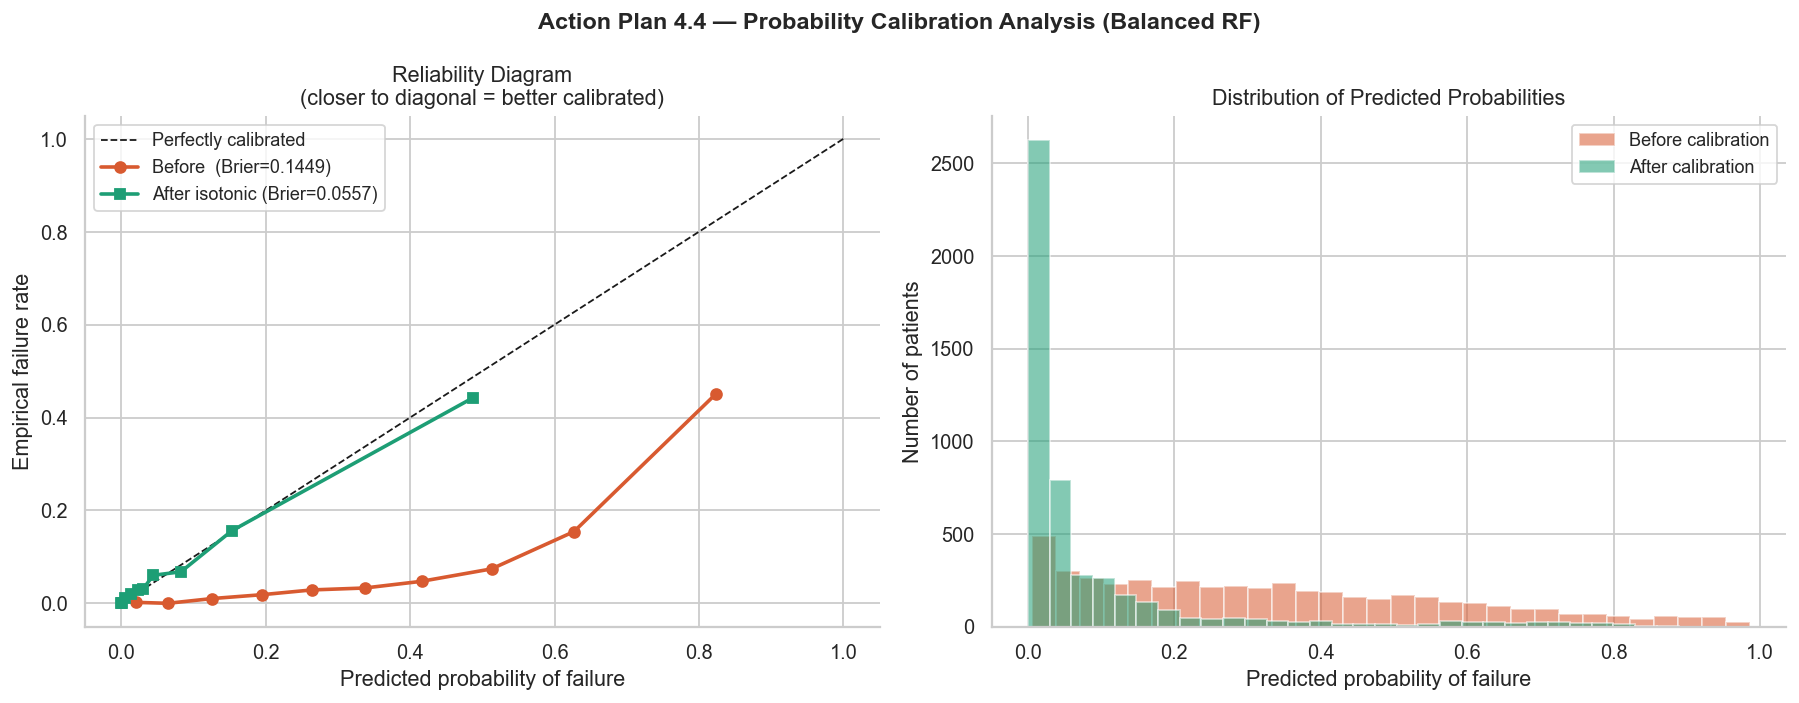

📏 Brier score (lower = more reliable probabilities):
   Before isotonic calibration : 0.1449
   After  isotonic calibration : 0.0557
   Δ = +0.0893  → ✅ improved
💾 Saved calibrated model → best_model_calibrated.pkl


In [28]:
# ─────────────────────────────────────────────────────────────
# STEP 6 — Probability Calibration Analysis (Action Plan 4.4)
# ─────────────────────────────────────────────────────────────
# WHY this matters clinically:
#   In ICU decision support, doctors don't just need a YES/NO label —
#   they need a *trustworthy* failure probability.  A patient with
#   p̂ = 0.30 should fail ~30% of the time in the real world.
#   Tree-based models + SMOTE-style oversampling are known to produce
#   miscalibrated (over-confident) probabilities, so we must check.
#
# WHAT we do:
#   1) Plot the reliability diagram (predicted prob vs. empirical freq.)
#      for the best model BEFORE calibration.
#   2) Wrap the best model in CalibratedClassifierCV (isotonic + 5-fold)
#      fit on the TRAINING data only — never on test.
#   3) Plot the reliability diagram AFTER calibration and report the
#      Brier score (lower = better calibrated).
# ─────────────────────────────────────────────────────────────
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.base import clone

# ── 1) Pre-calibration probabilities (already computed) ──
y_prob_uncal = results[best_name]['y_prob']
brier_before = brier_score_loss(y_test, y_prob_uncal)

# ── 2) Calibrate on TRAIN only, with internal 5-fold CV ──
calibrated = CalibratedClassifierCV(
    estimator=clone(best_model),
    method='isotonic',
    cv=5,
)
calibrated.fit(X_train, y_train)
y_prob_cal = calibrated.predict_proba(X_test)[:, 1]
brier_after = brier_score_loss(y_test, y_prob_cal)

# ── 3) Reliability diagrams ──
prob_true_b, prob_pred_b = calibration_curve(y_test, y_prob_uncal, n_bins=10, strategy='quantile')
prob_true_a, prob_pred_a = calibration_curve(y_test, y_prob_cal,   n_bins=10, strategy='quantile')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(f'Action Plan 4.4 — Probability Calibration Analysis ({best_name})',
             fontsize=13, fontweight='bold')

# Panel A: reliability curves
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfectly calibrated')
ax.plot(prob_pred_b, prob_true_b, 'o-', color='#D85A30', lw=2,
        label=f'Before  (Brier={brier_before:.4f})')
ax.plot(prob_pred_a, prob_true_a, 's-', color='#1D9E75', lw=2,
        label=f'After isotonic (Brier={brier_after:.4f})')
ax.set_xlabel('Predicted probability of failure')
ax.set_ylabel('Empirical failure rate')
ax.set_title('Reliability Diagram\n(closer to diagonal = better calibrated)')
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)

# Panel B: predicted-probability histograms
ax2 = axes[1]
ax2.hist(y_prob_uncal, bins=30, alpha=0.55, color='#D85A30',
         label='Before calibration', edgecolor='white')
ax2.hist(y_prob_cal,   bins=30, alpha=0.55, color='#1D9E75',
         label='After calibration',  edgecolor='white')
ax2.set_xlabel('Predicted probability of failure')
ax2.set_ylabel('Number of patients')
ax2.set_title('Distribution of Predicted Probabilities')
ax2.legend(fontsize=10)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('plot_calibration.png', dpi=150)
plt.show()

print('📏 Brier score (lower = more reliable probabilities):')
print(f'   Before isotonic calibration : {brier_before:.4f}')
print(f'   After  isotonic calibration : {brier_after:.4f}')
delta = brier_before - brier_after
verdict = '✅ improved' if delta > 0 else '⚠️ no improvement (model already well-calibrated)'
print(f'   Δ = {delta:+.4f}  → {verdict}')

# Save the calibrated model for clinical deployment
joblib.dump(calibrated, 'best_model_calibrated.pkl')
print('💾 Saved calibrated model → best_model_calibrated.pkl')